# Gemma Medical Quantization Benchmark

This Colab notebook measures how one configurable Gemma checkpoint performs on medical multiple-choice benchmarks when loaded as a BF16/FP16 baseline, BitsAndBytes INT8, and BitsAndBytes INT4 (NF4). Optional AWQ and GPTQ sections are isolated so the core benchmark remains usable without their extra dependencies.

**Start small.** The default sample limit validates the pipeline; it is not a publishable medical-AI result. Increase `MAX_SAMPLES_PER_DATASET`, run all configurations in the same uninterrupted Colab session, and review dataset/model licenses before drawing conclusions.

Locally measured results and manually entered published results are deliberately kept separate. Quantization does not guarantee faster generation; this notebook measures it.


## 1. Project overview

The experiment uses the same checkpoint, tokenizer, sampled examples, prompt, batch size, and generation settings for every local configuration. Each completed configuration saves raw predictions and summary metrics immediately under the configured output directory.


## 2. Research questions

1. Does quantization reduce medical benchmark accuracy?
2. How much does it improve measured inference speed?
3. How much GPU VRAM and model-cache disk space are saved?
4. Does INT8 or INT4 provide the better accuracy–efficiency trade-off?
5. How do local results relate—cautiously—to published medical-LLM results?


## 3. Colab GPU and environment check

Run this before installing packages. A CUDA GPU is required for the BitsAndBytes experiments. CPU-only execution is reported clearly and GPU configurations are recorded as failed rather than terminating the notebook.


In [1]:
import os, platform, subprocess, sys

def command_output(command):
    '''Return command output without failing the notebook.'''
    try:
        return subprocess.check_output(command, text=True, stderr=subprocess.STDOUT).strip()
    except Exception as exc:
        return f"Unavailable ({type(exc).__name__}: {exc})"

try:
    import torch
    gpu_available = torch.cuda.is_available()
    if gpu_available:
        props = torch.cuda.get_device_properties(0)
        print(f"GPU: {props.name}")
        print(f"Total GPU memory: {props.total_memory / 2**30:.2f} GiB")
    else:
        print("WARNING: No CUDA GPU is available. Select Runtime > Change runtime type > GPU.")
    print(f"CUDA reported by PyTorch: {torch.version.cuda}")
    print(f"PyTorch: {torch.__version__}")
except Exception as exc:
    print(f"PyTorch environment check failed: {exc}")

print(f"Python: {platform.python_version()}")
print("Driver / nvidia-smi:")
print(command_output(["nvidia-smi", "--query-gpu=name,memory.total,driver_version", "--format=csv,noheader"]))


GPU: Tesla T4
Total GPU memory: 14.56 GiB
CUDA reported by PyTorch: 12.8
PyTorch: 2.11.0+cu128
Python: 3.12.13
Driver / nvidia-smi:
Tesla T4, 15360 MiB, 580.82.07


## 4. Installation

The runtime-provided CUDA build of PyTorch and Colab's scientific stack (`numpy`, `pandas`, and `matplotlib`) are retained to avoid ABI conflicts with preinstalled CUDA, JAX, OpenCV, and geospatial packages. Only the benchmark-specific dependencies are installed. The Hugging Face v5 package set supports the Hub 1.x dependency already required by current Colab packages. After installation, restart the Colab runtime if prompted, then run the notebook from the top. Optional AWQ/GPTQ packages are installed only in their disabled-by-default section.


In [2]:
%pip install -q --upgrade --upgrade-strategy only-if-needed \
  "transformers==5.14.1" "datasets==5.0.0" "accelerate==1.14.0" \
  "bitsandbytes==0.49.2" "huggingface_hub>=1.2,<2" \
  "sentencepiece>=0.2,<0.3" "psutil>=5.9,<8" "tqdm>=4.67,<5"

# Diagnostic only: any remaining lines are pre-existing runtime conflicts.
!python -m pip check


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 116.4 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 50.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 18.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 784.9/784.9 kB 58.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.2/80.2 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 127.9 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 16.8 MB/s eta 0:00:00:00:0100:01
ipython 7.34.0 requires jedi, which is not installed.


## 5. Imports and random seed


In [3]:
import gc
import importlib.metadata as importlib_metadata
import json
import math
import os
import platform
import random
import re
import shutil
import statistics
import subprocess
import sys
import threading
import time
import traceback
import warnings
from contextlib import nullcontext
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import psutil
import torch
import transformers
from datasets import load_dataset
from huggingface_hub import HfApi, notebook_login, scan_cache_dir
from matplotlib import pyplot as plt
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, set_seed

def package_version(name):
    try:
        return importlib_metadata.version(name)
    except importlib_metadata.PackageNotFoundError:
        return "not installed"

print("Transformers:", transformers.__version__)
print("Datasets:", package_version("datasets"))
print("Accelerate:", package_version("accelerate"))
print("BitsAndBytes:", package_version("bitsandbytes"))


Transformers: 5.14.1
Datasets: 5.0.0
Accelerate: 1.14.0
BitsAndBytes: 0.49.2


## 6. Experiment configuration

`google/gemma-2-2b-it` is a valid example checkpoint at the time this notebook was authored; it may be gated. Change `MODEL_ID` to any compatible, accessible Gemma causal-language-model checkpoint. This notebook does **not** assume that a “Gemma 4” repository exists. Increase the sample limit only after a small end-to-end run succeeds.


In [4]:
MODEL_ID = "google/gemma-2-2b-it"
MODEL_REVISION = None  # Pin a commit hash for strict reproducibility.

RUN_BASELINE = True
RUN_INT8 = True
RUN_INT4 = True
RUN_AWQ = False  # Needs a pre-quantized repository in AWQ_MODEL_ID first.
RUN_GPTQ = False  # Needs a pre-quantized repository in GPTQ_MODEL_ID first.
RUN_HEALTHBENCH = False

# AWQ/GPTQ generally require a separately pre-quantized repository.
AWQ_MODEL_ID = None
GPTQ_MODEL_ID = None

BENCHMARKS = ["pubmedqa", "medqa", "medmcqa"]
DATASET_CONFIGS = {
    "pubmedqa": {"path": "qiaojin/PubMedQA", "name": "pqa_labeled", "split": "train", "revision": None},
    "medqa": {"path": "GBaker/MedQA-USMLE-4-options", "name": None, "split": "test", "revision": None},
    "medmcqa": {"path": "openlifescienceai/medmcqa", "name": None, "split": "validation", "revision": None},
    # HealthBench needs benchmark-specific graders; set a valid source and adapter before enabling.
    "healthbench": {"path": None, "name": None, "split": "test", "revision": None},
}

MAX_SAMPLES_PER_DATASET = 300
MAX_NEW_TOKENS = 16
BATCH_SIZE = 1  # Evaluation currently profiles one prompt at a time for clean latency measurements.
NUM_WARMUP_RUNS = 5
NUM_TIMED_RUNS = 30
RANDOM_SEED = 42
OUTPUT_DIR = "/content/gemma_medical_benchmark_results"

ENABLE_CPU_OFFLOAD_FALLBACK = False  # Slower; enable only if a model barely exceeds VRAM.
CPU_OFFLOAD_FOLDER = f"{OUTPUT_DIR}/offload"
TRUST_REMOTE_CODE = False

PROMPT_TEMPLATE = '''You are answering a medical multiple-choice question.

{context_block}Question:
{question}

Choices:
{choices}

Select the single best answer.
Respond with only one letter: {allowed_letters}.'''

GENERATION_PARAMETERS = {
    "do_sample": False,
    "max_new_tokens": MAX_NEW_TOKENS,
    "use_cache": True,
}

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)
set_seed(RANDOM_SEED)

assert BATCH_SIZE == 1, "This version intentionally supports BATCH_SIZE=1 for comparable per-sample latency."
print(f"Results will be written to {OUTPUT_DIR}")


Results will be written to /content/gemma_medical_benchmark_results


## 7. Hugging Face authentication

Never paste a token into notebook source. Some Gemma checkpoints and datasets require accepting a license on their Hugging Face page before login grants access. If all selected resources are public, login can be skipped.


In [5]:
# Run when the selected model or dataset is gated.
notebook_login()


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


## 8. Dataset loading

Dataset repositories occasionally change names, splits, or schemas. Edit `DATASET_CONFIGS` above if necessary. Failures are retained in `dataset_errors.json`; other datasets continue loading.


In [6]:
def save_json(data, filename):
    '''Write JSON atomically enough for routine Colab use.'''
    path = Path(OUTPUT_DIR) / filename
    temp_path = path.with_suffix(path.suffix + ".tmp")
    with temp_path.open("w", encoding="utf-8") as handle:
        json.dump(data, handle, indent=2, ensure_ascii=False, default=str)
    temp_path.replace(path)
    return path

def friendly_access_error(exc, resource):
    text = str(exc)
    if any(term in text.lower() for term in ("401", "403", "gated", "unauthorized")):
        return f"Access denied for {resource}. Accept its license and run notebook_login(). Original error: {text}"
    if any(term in text.lower() for term in ("not found", "404", "doesn't exist")):
        return f"Resource not found: {resource}. Check its ID, configuration, and split. Original error: {text}"
    return f"Could not load {resource}: {type(exc).__name__}: {text}"

raw_datasets = {}
dataset_errors = {}
requested_benchmarks = list(BENCHMARKS) + (["healthbench"] if RUN_HEALTHBENCH else [])

for benchmark in requested_benchmarks:
    cfg = DATASET_CONFIGS.get(benchmark, {})
    if not cfg.get("path"):
        dataset_errors[benchmark] = f"No dataset path configured for optional benchmark '{benchmark}'."
        print("SKIP:", dataset_errors[benchmark])
        continue
    try:
        kwargs = {"path": cfg["path"], "split": cfg["split"]}
        if cfg.get("name"):
            kwargs["name"] = cfg["name"]
        if cfg.get("revision"):
            kwargs["revision"] = cfg["revision"]
        raw_datasets[benchmark] = load_dataset(**kwargs)
        print(f"Loaded {benchmark}: {len(raw_datasets[benchmark]):,} rows")
    except Exception as exc:
        dataset_errors[benchmark] = friendly_access_error(exc, cfg.get("path", benchmark))
        print("ERROR:", dataset_errors[benchmark])

save_json(dataset_errors, "dataset_errors.json")


README.md:   0%|          | 0.00/5.19k [00:00<?, ?B/s]

pqa_labeled/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.08MB            

pqa_labeled/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Loaded pubmedqa: 1,000 rows


...

Generating train split:   0%|          | 0/182822 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/6150 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/4183 [00:00<?, ? examples/s]

Loaded medmcqa: 4,183 rows


PosixPath('/content/gemma_medical_benchmark_results/dataset_errors.json')

## 9. Dataset preprocessing

All supported datasets are normalized to `id`, `question`, letter-keyed `choices`, `answer`, and `benchmark`, with optional `context`. The adapters tolerate common field variants but fail loudly on unrecognized schemas. The deterministic sample is selected once and reused by every model configuration.


In [7]:
LETTERS = list("ABCDEFGHIJKLMNOPQRSTUVWXYZ")

def first_present(row, keys, default=None):
    for key in keys:
        if key in row and row[key] is not None:
            return row[key]
    return default

def normalize_answer(value, choices, benchmark):
    '''Map textual, letter, or numeric answers to a choice letter.'''
    if value is None:
        return None
    labels = list(choices)
    text = str(value).strip()
    lowered = text.lower()
    if benchmark == "pubmedqa":
        return {"yes": "A", "no": "B", "maybe": "C", "a": "A", "b": "B", "c": "C"}.get(lowered)
    if text.upper() in labels:
        return text.upper()
    if lowered in {str(v).strip().lower() for v in choices.values()}:
        for label, choice_text in choices.items():
            if lowered == str(choice_text).strip().lower():
                return label
    try:
        number = int(value)
        # MedMCQA's `cop` is zero-based. Other common numeric answers may be one-based.
        if benchmark == "medmcqa" and 0 <= number < len(labels):
            return labels[number]
        if 1 <= number <= len(labels):
            return labels[number - 1]
        if 0 <= number < len(labels):
            return labels[number]
    except (TypeError, ValueError):
        pass
    match = re.search(r"\b([A-Z])\b", text.upper())
    return match.group(1) if match and match.group(1) in labels else None

def normalize_choices(value, row, benchmark):
    if benchmark == "pubmedqa":
        return {"A": "Yes", "B": "No", "C": "Maybe"}
    if isinstance(value, dict):
        # Some datasets store {label: [...], text: [...]}.
        if isinstance(value.get("label"), (list, tuple)) and isinstance(value.get("text"), (list, tuple)):
            return {str(k).upper(): str(v) for k, v in zip(value["label"], value["text"])}
        normalized = {}
        for key, item in value.items():
            key_text = str(key).strip().upper()
            if key_text in LETTERS:
                normalized[key_text] = str(item)
        if normalized:
            return dict(sorted(normalized.items(), key=lambda pair: LETTERS.index(pair[0])))
    if isinstance(value, (list, tuple)):
        return {LETTERS[i]: str(item) for i, item in enumerate(value)}
    option_fields = [
        ["opa", "option_a", "choice_a", "A"], ["opb", "option_b", "choice_b", "B"],
        ["opc", "option_c", "choice_c", "C"], ["opd", "option_d", "choice_d", "D"],
        ["ope", "option_e", "choice_e", "E"],
    ]
    choices = {}
    for i, aliases in enumerate(option_fields):
        item = first_present(row, aliases)
        if item is not None and str(item).strip():
            choices[LETTERS[i]] = str(item)
    return choices

def normalize_context(value):
    if value is None:
        return ""
    if isinstance(value, dict):
        value = first_present(value, ["contexts", "context", "text"], value)
    if isinstance(value, (list, tuple)):
        return "\n".join(str(item) for item in value if item is not None)
    return str(value)

def normalize_row(row, benchmark, row_index):
    question = first_present(row, ["question", "question_stem", "query", "prompt"])
    choice_value = first_present(row, ["choices", "options", "answer_options"])
    choices = normalize_choices(choice_value, row, benchmark)
    answer_value = first_present(row, ["answer_idx", "answer", "label", "cop", "correct", "final_decision"])
    answer = normalize_answer(answer_value, choices, benchmark)
    sample_id = first_present(row, ["id", "question_id", "qid", "pubid", "uid"], f"{benchmark}-{row_index}")
    context = normalize_context(first_present(row, ["context", "contexts", "long_answer"]))
    return {
        "id": str(sample_id), "question": "" if question is None else str(question).strip(),
        "choices": choices, "answer": answer, "benchmark": benchmark, "context": context.strip(),
    }

def validate_samples(samples):
    '''Return valid samples and structured validation errors.'''
    valid, errors, seen = [], [], set()
    for sample in samples:
        problems = []
        if not sample["question"]:
            problems.append("missing question")
        if len(sample["choices"]) < 2 or any(not str(v).strip() for v in sample["choices"].values()):
            problems.append("missing/insufficient choices")
        if sample["answer"] not in sample["choices"]:
            problems.append(f"invalid answer label: {sample['answer']!r}")
        unique_key = f"{sample['benchmark']}::{sample['id']}"
        if unique_key in seen:
            problems.append("duplicate sample ID")
        seen.add(unique_key)
        if problems:
            errors.append({"id": sample["id"], "benchmark": sample["benchmark"], "problems": problems})
        else:
            valid.append(sample)
    return valid, errors

normalized_datasets, preprocessing_errors, sample_ids = {}, {}, {}
for benchmark, dataset in raw_datasets.items():
    try:
        candidates = [normalize_row(row, benchmark, i) for i, row in enumerate(dataset)]
        valid, errors = validate_samples(candidates)
        rng = random.Random(f"{RANDOM_SEED}:{benchmark}")
        selected_indices = list(range(len(valid)))
        rng.shuffle(selected_indices)
        selected = [valid[i] for i in selected_indices[: min(MAX_SAMPLES_PER_DATASET, len(valid))]]
        normalized_datasets[benchmark] = selected
        preprocessing_errors[benchmark] = errors[:1000]
        sample_ids[benchmark] = [item["id"] for item in selected]
        print(f"{benchmark}: {len(selected)} selected, {len(errors)} rejected")
    except Exception as exc:
        dataset_errors[benchmark] = f"Schema adapter failed: {type(exc).__name__}: {exc}"
        print(f"ERROR preprocessing {benchmark}: {dataset_errors[benchmark]}")

if not normalized_datasets:
    print("WARNING: No benchmark is ready. Fix dataset access/configuration before model evaluation.")
save_json(preprocessing_errors, "preprocessing_errors.json")
save_json(sample_ids, "sample_ids.json")
save_json({
    "model_id": MODEL_ID, "requested_model_revision": MODEL_REVISION,
    "dataset_configs": DATASET_CONFIGS, "benchmarks": BENCHMARKS,
    "max_samples_per_dataset": MAX_SAMPLES_PER_DATASET, "batch_size": BATCH_SIZE,
    "random_seed": RANDOM_SEED, "prompt_template": PROMPT_TEMPLATE,
    "generation_parameters": GENERATION_PARAMETERS, "sample_ids": sample_ids,
    "note": "Pre-experiment checkpoint; the final saving cell adds resolved revisions and environment metadata.",
}, "experiment_config.json")


pubmedqa: 100 selected, 0 rejected
medqa: 100 selected, 0 rejected
medmcqa: 100 selected, 0 rejected


PosixPath('/content/gemma_medical_benchmark_results/experiment_config.json')

## 10. Prompt formatting

The same deterministic prompt is used for every local configuration. PubMedQA includes its supplied abstract context and allows A/B/C; four-option datasets allow A/B/C/D. A tokenizer chat template is used when the selected tokenizer exposes one, without changing the underlying user prompt.


In [8]:
def format_plain_prompt(sample):
    context_block = f"Context:\n{sample['context']}\n\n" if sample.get("context") else ""
    choices = "\n".join(f"{label}. {text}" for label, text in sample["choices"].items())
    allowed = ", ".join(sample["choices"].keys())
    return PROMPT_TEMPLATE.format(
        context_block=context_block, question=sample["question"], choices=choices, allowed_letters=allowed
    )

def format_model_prompt(sample, tokenizer):
    plain = format_plain_prompt(sample)
    if getattr(tokenizer, "chat_template", None):
        try:
            return tokenizer.apply_chat_template(
                [{"role": "user", "content": plain}], tokenize=False, add_generation_prompt=True
            )
        except Exception as exc:
            warnings.warn(f"Chat template failed; using plain prompt: {exc}")
    return plain

def extract_answer(output, choices):
    '''Map a model response to a choice letter, or return INVALID.

    `choices` may be the {letter: text} mapping, which also resolves answers written
    out in words such as PubMedQA's "Yes", or just the choice letters.
    '''
    if output is None or not str(output).strip():
        return "INVALID"
    labels = list(choices)
    choice_texts = choices if isinstance(choices, dict) else {}
    text = str(output).strip()
    # A leading letter counts only when it stands alone or is followed by punctuation.
    # "A patient presents with..." is prose, not choice A.
    patterns = [
        r"^\s*\(?([A-Za-z])\)?\s*(?:[\.\):,-]|$)",
        r"\banswer\s*(?:is|:)?\s*\(?([A-Za-z])\)?(?![A-Za-z])",
        r"\bcorrect\s+answer\s*(?:is|:)?\s*\(?([A-Za-z])\)?(?![A-Za-z])",
    ]
    for pattern in patterns:
        match = re.search(pattern, text, flags=re.IGNORECASE)
        if match and match.group(1).upper() in labels:
            return match.group(1).upper()
    # Models often answer with the choice text itself instead of its letter.
    if choice_texts:
        stripped = re.sub(r"^(?:the\s+)?(?:correct\s+)?answer\s*(?:is|:)\s*", "", text, flags=re.IGNORECASE)
        stripped = stripped.strip().strip(".,:;!?()[]\"'").casefold()
        matched = {label for label, choice in choice_texts.items()
                   if stripped and stripped == str(choice).strip().casefold()}
        if len(matched) == 1:
            return matched.pop()
    return "INVALID"

# Self-check covering letter answers, worded answers, and prose that must not be scored.
PUBMEDQA_CHOICES = {"A": "Yes", "B": "No", "C": "Maybe"}
for example, example_choices, expected in [
    ("A", list("ABCD"), "A"), ("A.", list("ABCD"), "A"), ("Answer: A", list("ABCD"), "A"),
    ("The correct answer is B", list("ABCD"), "B"), ("(C)", list("ABCD"), "C"),
    ("unsure", list("ABCD"), "INVALID"), ("a", list("ABCD"), "A"),
    ("A patient with chest pain should get D", list("ABCD"), "INVALID"),
    ("A 45-year-old man presents with dyspnea", list("ABCD"), "INVALID"),
    ("D is wrong; the answer is A", list("ABCD"), "A"),
    ("Yes", PUBMEDQA_CHOICES, "A"), ("No", PUBMEDQA_CHOICES, "B"),
    ("Maybe.", PUBMEDQA_CHOICES, "C"), ("The answer is Yes", PUBMEDQA_CHOICES, "A"),
    ("Possibly yes but the evidence is weak", PUBMEDQA_CHOICES, "INVALID"),
]:
    assert extract_answer(example, example_choices) == expected, (example, expected)


## 11. Model loading

The baseline selects BF16 only when CUDA reports BF16 support; otherwise it uses FP16. BitsAndBytes quantization method and numerical precision are reported separately. `device_map="auto"` is used, and explicit CPU offloading is an opt-in fallback because it changes performance substantially.


In [9]:
def cuda_sync():
    if torch.cuda.is_available():
        torch.cuda.synchronize()

def gpu_memory_snapshot():
    if not torch.cuda.is_available():
        return {"allocated_gib": 0.0, "reserved_gib": 0.0, "device_used_gib": None}
    allocated = torch.cuda.memory_allocated() / 2**30
    reserved = torch.cuda.memory_reserved() / 2**30
    try:
        used_mib = subprocess.check_output(
            ["nvidia-smi", "--query-compute-apps=used_memory", "--format=csv,noheader,nounits"], text=True
        ).strip().splitlines()
        device_used = sum(float(x) for x in used_mib if x.strip()) / 1024
    except Exception:
        device_used = None
    return {"allocated_gib": allocated, "reserved_gib": reserved, "device_used_gib": device_used}

class PeakRSSMonitor:
    '''Sample this process and its children to approximate peak resident CPU RAM.'''
    def __init__(self, interval=0.05):
        self.interval, self.peak_bytes, self._stop = interval, 0, threading.Event()
        self._thread = None
    def _rss(self):
        process = psutil.Process()
        total = process.memory_info().rss
        for child in process.children(recursive=True):
            try:
                total += child.memory_info().rss
            except (psutil.NoSuchProcess, psutil.AccessDenied):
                pass
        return total
    def _run(self):
        while not self._stop.is_set():
            self.peak_bytes = max(self.peak_bytes, self._rss())
            self._stop.wait(self.interval)
    def start(self):
        self.peak_bytes = self._rss()
        self._thread = threading.Thread(target=self._run, daemon=True)
        self._thread.start()
        return self
    def stop(self):
        self._stop.set()
        if self._thread:
            self._thread.join(timeout=1)
        self.peak_bytes = max(self.peak_bytes, self._rss())
        return self.peak_bytes / 2**30

def choose_baseline_dtype():
    if not torch.cuda.is_available():
        raise RuntimeError("No CUDA GPU. Baseline GPU benchmark was skipped.")
    if hasattr(torch.cuda, "is_bf16_supported") and torch.cuda.is_bf16_supported():
        return torch.bfloat16, "BF16"
    warnings.warn("BF16 is unsupported on this GPU; falling back to FP16.")
    return torch.float16, "FP16"

def bf16_supported():
    return bool(torch.cuda.is_available() and hasattr(torch.cuda, "is_bf16_supported") and torch.cuda.is_bf16_supported())

def common_model_kwargs(model_id):
    kwargs = {
        "pretrained_model_name_or_path": model_id,
        "revision": MODEL_REVISION,
        # Keep every default run on one GPU. Opt-in fallback below permits CPU/disk placement.
        "device_map": "auto" if ENABLE_CPU_OFFLOAD_FALLBACK else {"": 0},
        "low_cpu_mem_usage": True,
        "trust_remote_code": TRUST_REMOTE_CODE,
    }
    if ENABLE_CPU_OFFLOAD_FALLBACK:
        Path(CPU_OFFLOAD_FOLDER).mkdir(parents=True, exist_ok=True)
        kwargs.update({"offload_folder": CPU_OFFLOAD_FOLDER, "offload_state_dict": True})
    return kwargs

def load_tokenizer(model_id=MODEL_ID):
    tokenizer = AutoTokenizer.from_pretrained(
        model_id, revision=MODEL_REVISION, trust_remote_code=TRUST_REMOTE_CODE
    )
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "left"
    return tokenizer

def load_baseline_model():
    dtype, dtype_name = choose_baseline_dtype()
    kwargs = common_model_kwargs(MODEL_ID)
    kwargs["dtype"] = dtype
    model = AutoModelForCausalLM.from_pretrained(**kwargs)
    return model.eval(), dtype_name, "None"

def load_int8_model():
    if not torch.cuda.is_available():
        raise RuntimeError("BitsAndBytes INT8 requires a supported CUDA GPU.")
    kwargs = common_model_kwargs(MODEL_ID)
    kwargs["quantization_config"] = BitsAndBytesConfig(load_in_8bit=True)
    model = AutoModelForCausalLM.from_pretrained(**kwargs)
    return model.eval(), "INT8 weights (mixed compute)", "BitsAndBytes"

def load_int4_model():
    if not torch.cuda.is_available():
        raise RuntimeError("BitsAndBytes INT4 requires a supported CUDA GPU.")
    compute_dtype = torch.bfloat16 if bf16_supported() else torch.float16
    kwargs = common_model_kwargs(MODEL_ID)
    kwargs["quantization_config"] = BitsAndBytesConfig(
        load_in_4bit=True, bnb_4bit_quant_type="nf4", bnb_4bit_use_double_quant=True,
        bnb_4bit_compute_dtype=compute_dtype,
    )
    model = AutoModelForCausalLM.from_pretrained(**kwargs)
    return model.eval(), f"INT4 NF4 (compute {str(compute_dtype).replace('torch.', '')})", "BitsAndBytes"

def unload_model():
    '''Collect already-released references and clear PyTorch's reusable CUDA cache.'''
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

def model_input_device(model):
    try:
        device = model.get_input_embeddings().weight.device
        if device.type != "meta":
            return device
    except Exception:
        pass
    return torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

def cached_model_size_gib(model_id):
    '''Return cache size for the repository when discoverable (not in-memory weight size).'''
    try:
        cache = scan_cache_dir()
        repo = next((r for r in cache.repos if r.repo_id == model_id and r.repo_type == "model"), None)
        return repo.size_on_disk / 2**30 if repo else None
    except Exception:
        return None


## 12. BF16 or FP16 baseline evaluation

Register the unquantized baseline. Its actual BF16/FP16 dtype is chosen and reported at load time.


In [10]:
EXPERIMENTS = []
if RUN_BASELINE:
    EXPERIMENTS.append(("Baseline", True, load_baseline_model))


## 13. INT8 evaluation

Register BitsAndBytes INT8. A failure here is saved without preventing INT4 from running.


In [11]:
if RUN_INT8:
    EXPERIMENTS.append(("INT8", True, load_int8_model))


## 14. INT4 NF4 evaluation

Register BitsAndBytes INT4 NF4, then run all enabled core configurations serially. The engine saves completed work after every configuration, captures load/evaluation errors (including CUDA OOM and access problems), and clears GPU memory before continuing.


In [12]:
if RUN_INT4:
    EXPERIMENTS.append(("INT4-NF4", True, load_int4_model))


In [13]:
@torch.inference_mode()
def generate_once(model, tokenizer, prompt, max_new_tokens=MAX_NEW_TOKENS):
    inputs = tokenizer(prompt, return_tensors="pt")
    input_length = inputs["input_ids"].shape[-1]
    inputs = {key: value.to(model_input_device(model)) for key, value in inputs.items()}
    cuda_sync()
    start = time.perf_counter()
    output_ids = model.generate(
        **inputs, do_sample=False, max_new_tokens=max_new_tokens,
        use_cache=GENERATION_PARAMETERS["use_cache"],
        pad_token_id=tokenizer.pad_token_id,
    )
    cuda_sync()
    latency = time.perf_counter() - start
    new_ids = output_ids[:, input_length:]
    new_token_count = int(new_ids.shape[-1])
    response = tokenizer.decode(new_ids[0], skip_special_tokens=True).strip()
    return response, new_token_count, latency

def wilson_interval(correct, total, z=1.959963984540054):
    if total <= 0:
        return (math.nan, math.nan)
    p = correct / total
    denominator = 1 + z*z/total
    center = (p + z*z/(2*total)) / denominator
    margin = z * math.sqrt((p*(1-p) + z*z/(4*total))/total) / denominator
    return max(0.0, center-margin), min(1.0, center+margin)

def evaluate_accuracy(model, tokenizer, config_name):
    records = []
    for benchmark, samples in normalized_datasets.items():
        for sample in tqdm(samples, desc=f"{config_name} · {benchmark}"):
            prompt = format_model_prompt(sample, tokenizer)
            try:
                response, token_count, latency = generate_once(model, tokenizer, prompt)
                prediction = extract_answer(response, sample["choices"])
                error = None if response else "Empty model output"
            except torch.cuda.OutOfMemoryError as exc:
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()
                response, prediction, token_count, latency = "", "INVALID", 0, math.nan
                error = f"CUDA OOM: {exc}"
            except Exception as exc:
                response, prediction, token_count, latency = "", "INVALID", 0, math.nan
                error = f"{type(exc).__name__}: {exc}"
            records.append({
                "model_configuration": config_name, "benchmark": benchmark, "sample_id": sample["id"],
                "gold_answer": sample["answer"], "predicted_answer": prediction,
                "is_correct": prediction == sample["answer"], "is_valid": prediction in sample["choices"],
                "raw_response": response, "generated_tokens": token_count,
                "latency_seconds": latency, "error": error,
            })
    return records

def profile_performance(model, tokenizer, config_name):
    all_samples = [sample for samples in normalized_datasets.values() for sample in samples]
    if not all_samples:
        raise RuntimeError("No normalized samples are available for profiling.")
    prompts = [format_model_prompt(item, tokenizer) for item in all_samples]
    for i in range(NUM_WARMUP_RUNS):
        generate_once(model, tokenizer, prompts[i % len(prompts)])
    latencies, ttfts, tokens = [], [], []
    for i in tqdm(range(NUM_TIMED_RUNS), desc=f"Profiling {config_name}"):
        prompt = prompts[i % len(prompts)]
        _, count, latency = generate_once(model, tokenizer, prompt)
        _, _, ttft = generate_once(model, tokenizer, prompt, max_new_tokens=1)
        latencies.append(latency)
        ttfts.append(ttft)
        tokens.append(count)
    return {
        "model_configuration": config_name,
        "tokens_per_second": sum(tokens) / sum(latencies) if sum(latencies) else math.nan,
        "mean_latency_seconds": statistics.fmean(latencies),
        "median_latency_seconds": statistics.median(latencies),
        "p95_latency_seconds": float(np.percentile(latencies, 95)),
        "mean_time_to_first_token_seconds": statistics.fmean(ttfts),
        "overall_samples_per_second": NUM_TIMED_RUNS / sum(latencies) if sum(latencies) else math.nan,
        "timed_runs": NUM_TIMED_RUNS,
    }

def summarize_predictions(records):
    rows = []
    if not records:
        return rows
    frame = pd.DataFrame(records)
    for (configuration, benchmark), group in frame.groupby(["model_configuration", "benchmark"]):
        total, correct = len(group), int(group["is_correct"].sum())
        valid = int(group["is_valid"].sum())
        low, high = wilson_interval(correct, total)
        rows.append({
            "model_configuration": configuration, "benchmark": benchmark,
            "total_evaluated": total, "correct": correct, "incorrect": total-correct-int((~group["is_valid"]).sum()),
            "invalid": int((~group["is_valid"]).sum()), "accuracy": correct/total if total else math.nan,
            "valid_response_rate": valid/total if total else math.nan,
            "accuracy_excluding_invalid": int((group["is_correct"] & group["is_valid"]).sum())/valid if valid else math.nan,
            "accuracy_ci95_low": low, "accuracy_ci95_high": high,
        })
    return rows

def save_running_results(predictions, performance, memory, failures):
    pd.DataFrame(predictions).to_csv(Path(OUTPUT_DIR) / "raw_predictions.csv", index=False)
    pd.DataFrame(summarize_predictions(predictions)).to_csv(Path(OUTPUT_DIR) / "benchmark_summary.csv", index=False)
    pd.DataFrame(performance).to_csv(Path(OUTPUT_DIR) / "performance_summary.csv", index=False)
    pd.DataFrame(memory).to_csv(Path(OUTPUT_DIR) / "memory_summary.csv", index=False)
    save_json(failures, "experiment_failures.json")

all_predictions, performance_rows, memory_rows, experiment_failures = [], [], [], []
session_gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else None

for config_name, enabled, loader in EXPERIMENTS:
    if not enabled:
        continue
    model = tokenizer = None
    unload_model()
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()
    before = gpu_memory_snapshot()
    ram_monitor = PeakRSSMonitor().start()
    try:
        print(f"\n=== {config_name} ===")
        tokenizer = load_tokenizer()
        cuda_sync()
        load_start = time.perf_counter()
        model, actual_dtype, quant_method = loader()
        cuda_sync()
        load_time = time.perf_counter() - load_start
        after_load = gpu_memory_snapshot()
        predictions = evaluate_accuracy(model, tokenizer, config_name)
        profile = profile_performance(model, tokenizer, config_name)
        profile["load_time_seconds"] = load_time
        profile["gpu_name"] = torch.cuda.get_device_name(0) if torch.cuda.is_available() else None
        performance_rows.append(profile)
        all_predictions.extend(predictions)
        peak_ram = ram_monitor.stop()
        memory_rows.append({
            "model_configuration": config_name, "actual_dtype": actual_dtype,
            "quantization_method": quant_method,
            "gpu_allocated_before_load_gib": before["allocated_gib"],
            "gpu_device_used_before_load_gib": before["device_used_gib"],
            "gpu_allocated_after_load_gib": after_load["allocated_gib"],
            "gpu_device_used_after_load_gib": after_load["device_used_gib"],
            "peak_allocated_vram_gib": torch.cuda.max_memory_allocated()/2**30 if torch.cuda.is_available() else 0,
            "peak_reserved_vram_gib": torch.cuda.max_memory_reserved()/2**30 if torch.cuda.is_available() else 0,
            "peak_cpu_ram_gib": peak_ram, "model_cache_size_gib": cached_model_size_gib(MODEL_ID),
        })
    except Exception as exc:
        peak_ram = ram_monitor.stop()
        message = friendly_access_error(exc, MODEL_ID)
        if isinstance(exc, torch.cuda.OutOfMemoryError) or "out of memory" in str(exc).lower():
            message = f"CUDA out of memory during {config_name}. Reduce model/sample size or explicitly enable CPU offload. {exc}"
        elif "bitsandbytes" in str(exc).lower():
            message = f"BitsAndBytes incompatibility during {config_name}: {exc}"
        experiment_failures.append({"model_configuration": config_name, "error": message, "traceback": traceback.format_exc()})
        print("FAILED:", message)
    finally:
        save_running_results(all_predictions, performance_rows, memory_rows, experiment_failures)
        del model
        del tokenizer
        unload_model()

if torch.cuda.is_available() and torch.cuda.get_device_name(0) != session_gpu_name:
    warnings.warn("GPU identity changed during this session. Do not compare these runs directly.")



=== Baseline ===


config.json:   0%|          | 0.00/838 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/47.0k [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.5MB            

tokenizer.json: downloading bytes:           |  0.00B            

...

INT4-NF4 · pubmedqa:   0%|          | 0/100 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


INT4-NF4 · medqa:   0%|          | 0/100 [00:00<?, ?it/s]

INT4-NF4 · medmcqa:   0%|          | 0/100 [00:00<?, ?it/s]

Profiling INT4-NF4:   0%|          | 0/5 [00:00<?, ?it/s]

## 15. Optional AWQ or GPTQ evaluation

AWQ/GPTQ are **not** equivalent to loading the base checkpoint with a flag; they normally require compatible pre-quantized repositories. This cell installs optional packages only when enabled, requires the matching model ID, reuses the same evaluator, and records failures without affecting core results. Package ecosystems can conflict with the pinned core stack, so a separate fresh runtime is often the most reproducible approach.


In [14]:
def install_optional_quantizer(kind):
    package = "autoawq" if kind == "AWQ" else "auto-gptq"
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

def load_prequantized_model(model_id, kind):
    if not torch.cuda.is_available():
        raise RuntimeError(f"{kind} evaluation requires a supported CUDA GPU.")
    if not model_id:
        raise ValueError(f"Set {kind}_MODEL_ID to a compatible pre-quantized repository.")
    kwargs = common_model_kwargs(model_id)
    kwargs["pretrained_model_name_or_path"] = model_id
    model = AutoModelForCausalLM.from_pretrained(**kwargs)
    return model.eval(), f"INT4 ({kind} repository metadata)", kind

OPTIONAL_EXPERIMENTS = [("AWQ-INT4", RUN_AWQ, AWQ_MODEL_ID, "AWQ"),
                        ("GPTQ-INT4", RUN_GPTQ, GPTQ_MODEL_ID, "GPTQ")]
for config_name, enabled, optional_model_id, method in OPTIONAL_EXPERIMENTS:
    if not enabled:
        print(f"{config_name}: disabled")
        continue
    model = tokenizer = None
    unload_model()
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()
    before = gpu_memory_snapshot()
    monitor = PeakRSSMonitor().start()
    try:
        install_optional_quantizer(method)
        tokenizer = load_tokenizer(optional_model_id)
        cuda_sync(); start = time.perf_counter()
        model, actual_dtype, quant_method = load_prequantized_model(optional_model_id, method)
        cuda_sync(); load_time = time.perf_counter() - start
        after = gpu_memory_snapshot()
        all_predictions.extend(evaluate_accuracy(model, tokenizer, config_name))
        profile = profile_performance(model, tokenizer, config_name)
        profile.update({"load_time_seconds": load_time, "gpu_name": torch.cuda.get_device_name(0)})
        performance_rows.append(profile)
        peak_ram = monitor.stop()
        memory_rows.append({
            "model_configuration": config_name, "actual_dtype": actual_dtype,
            "quantization_method": quant_method, "gpu_allocated_before_load_gib": before["allocated_gib"],
            "gpu_device_used_before_load_gib": before["device_used_gib"],
            "gpu_allocated_after_load_gib": after["allocated_gib"],
            "gpu_device_used_after_load_gib": after["device_used_gib"],
            "peak_allocated_vram_gib": torch.cuda.max_memory_allocated()/2**30,
            "peak_reserved_vram_gib": torch.cuda.max_memory_reserved()/2**30,
            "peak_cpu_ram_gib": peak_ram, "model_cache_size_gib": cached_model_size_gib(optional_model_id),
        })
    except Exception as exc:
        monitor.stop()
        experiment_failures.append({"model_configuration": config_name, "error": f"{type(exc).__name__}: {exc}",
                                    "traceback": traceback.format_exc()})
        print(f"Optional {config_name} skipped/failed: {exc}")
    finally:
        save_running_results(all_predictions, performance_rows, memory_rows, experiment_failures)
        del model
        del tokenizer
        unload_model()


Optional AWQ-INT4 skipped/failed: None is not a local folder and is not a valid model identifier listed on 'https://huggingface.co/models'
If this is a private repository, make sure to pass a token having permission to this repo either by logging in with `hf auth login` or by passing `token=<your_token>`
Optional GPTQ-INT4 skipped/failed: Command '['/usr/bin/python3', '-m', 'pip', 'install', '-q', 'auto-gptq']' returned non-zero exit status 1.


## 16. Accuracy calculation

Primary accuracy is `correct / all evaluated`, so invalid generations count against the model. Accuracy excluding invalid responses is secondary. Wilson 95% binomial confidence intervals are included; with small samples they will be wide, and the default run should be treated only as pipeline validation.


In [15]:
benchmark_summary = pd.DataFrame(summarize_predictions(all_predictions))
benchmark_summary.to_csv(Path(OUTPUT_DIR) / "benchmark_summary.csv", index=False)
display(benchmark_summary.round(4) if not benchmark_summary.empty else pd.DataFrame({"status": ["No completed predictions"]}))


,model_configuration,benchmark,total_evaluated,correct,incorrect,invalid,accuracy,valid_response_rate,accuracy_excluding_invalid,accuracy_ci95_low,accuracy_ci95_high
0,Baseline,medmcqa,100,21,33,46,0.21,0.54,0.3889,0.1417,0.2998
1,Baseline,medqa,100,2,2,96,0.02,0.04,0.5000,0.0055,0.0700
2,Baseline,pubmedqa,100,43,35,22,0.43,0.78,0.5513,0.3373,0.5278
3,INT4-NF4,medmcqa,100,23,29,48,0.23,0.52,0.4423,0.1584,0.3215
4,INT4-NF4,medqa,100,2,2,96,0.02,0.04,0.5000,0.0055,0.0700
5,INT4-NF4,pubmedqa,100,41,32,27,0.41,0.73,0.5616,0.3187,0.5080
6,INT8,medmcqa,100,27,31,42,0.27,0.58,0.4655,0.1927,0.3643
7,INT8,medqa,100,4,2,94,0.04,0.06,0.6667,0.0157,0.0984
8,INT8,pubmedqa,100,39,40,21,0.39,0.79,0.4937,0.3002,0.4880


## 17. Performance profiling

Warm-up runs occur before timing. CUDA is synchronized around generation. End-to-end latency excludes model loading; tokens/second uses the actual number of newly generated token IDs, not character count. Time to first token is approximated by a separate one-token `generate` call and therefore includes generation setup overhead. Overall benchmark throughput is the reciprocal of summed full-generation latency; it is a single-request, batch-size-one measurement rather than a serving-system benchmark.


In [16]:
performance_summary = pd.DataFrame(performance_rows)
performance_summary.to_csv(Path(OUTPUT_DIR) / "performance_summary.csv", index=False)
display(performance_summary.round(4) if not performance_summary.empty else pd.DataFrame({"status": ["No completed profiles"]}))


,model_configuration,tokens_per_second,mean_latency_seconds,median_latency_seconds,p95_latency_seconds,mean_time_to_first_token_seconds,overall_samples_per_second,timed_runs,load_time_seconds,gpu_name
0,Baseline,7.4390,1.1830,1.0717,1.6021,0.8182,0.8453,5,63.7030,Tesla T4
1,INT8,5.6523,1.9815,2.6679,2.9262,0.2532,0.5047,5,17.1653,Tesla T4
2,INT4-NF4,6.6084,1.6948,1.9941,2.1621,0.8529,0.5900,5,2.4215,Tesla T4


## 18. Memory profiling

Allocated VRAM is memory occupied by live tensors; reserved VRAM is the larger CUDA caching-allocator pool; total GPU memory is hardware capacity. `nvidia-smi` device-used memory also includes CUDA context/library allocations. Peak CPU RAM is sampled RSS for the notebook process and children. Cache size is repository disk usage, not runtime model memory, and shared cached files can complicate interpretation.


In [17]:
memory_summary = pd.DataFrame(memory_rows)
memory_summary.to_csv(Path(OUTPUT_DIR) / "memory_summary.csv", index=False)
display(memory_summary.round(4) if not memory_summary.empty else pd.DataFrame({"status": ["No completed memory profiles"]}))


,model_configuration,actual_dtype,quantization_method,gpu_allocated_before_load_gib,gpu_device_used_before_load_gib,gpu_allocated_after_load_gib,gpu_device_used_after_load_gib,peak_allocated_vram_gib,peak_reserved_vram_gib,peak_cpu_ram_gib,model_cache_size_gib
0,Baseline,BF16,None,0.0000,0.0000,4.8696,4.9863,5.0163,5.1113,6.2565,4.886
1,INT8,INT8 weights (mixed compute),BitsAndBytes,0.0079,0.1445,2.9959,3.2305,3.1399,3.2305,7.6985,4.886
2,INT4-NF4,INT4 NF4 (compute bfloat16),BitsAndBytes,0.0089,0.1562,2.0861,2.2637,2.2282,2.3320,7.6872,4.886


## 19. Comparison tables

The baseline is the locally loaded BF16/FP16 model. Accuracy drop is baseline minus quantized accuracy; positive values mean degradation. Speedup is quantized tokens/s divided by baseline tokens/s. VRAM reduction uses peak allocated VRAM.


In [18]:
def build_comparison_tables(benchmark_df, performance_df, memory_df):
    if benchmark_df.empty:
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame(), pd.DataFrame()
    accuracy_pivot = benchmark_df.pivot(index="model_configuration", columns="benchmark", values="accuracy")
    valid = benchmark_df.groupby("model_configuration")["valid_response_rate"].mean()
    accuracy_table = accuracy_pivot.rename(columns={
        "pubmedqa": "PubMedQA Accuracy", "medqa": "MedQA Accuracy", "medmcqa": "MedMCQA Accuracy"
    }).reset_index().rename(columns={"model_configuration": "Model Configuration"})
    accuracy_table["Valid Response Rate"] = accuracy_table["Model Configuration"].map(valid)

    perf_columns = {"model_configuration": "Model Configuration", "tokens_per_second": "Tokens/sec",
                    "mean_latency_seconds": "Mean Latency", "median_latency_seconds": "Median Latency",
                    "p95_latency_seconds": "P95 Latency", "load_time_seconds": "Load Time"}
    performance_table = performance_df[[c for c in perf_columns if c in performance_df]].rename(columns=perf_columns)
    mem_columns = {"model_configuration": "Model Configuration", "actual_dtype": "Actual Dtype",
                   "quantization_method": "Quantization Method", "peak_allocated_vram_gib": "Peak VRAM",
                   "peak_reserved_vram_gib": "Reserved VRAM", "peak_cpu_ram_gib": "Peak RAM"}
    memory_table = memory_df[[c for c in mem_columns if c in memory_df]].rename(columns=mem_columns)

    avg_accuracy = benchmark_df.groupby("model_configuration")["accuracy"].mean()
    perf_index = performance_df.set_index("model_configuration") if not performance_df.empty else pd.DataFrame()
    mem_index = memory_df.set_index("model_configuration") if not memory_df.empty else pd.DataFrame()
    baseline_acc = avg_accuracy.get("Baseline", math.nan)
    baseline_speed = perf_index["tokens_per_second"].get("Baseline", math.nan) if not perf_index.empty else math.nan
    baseline_vram = mem_index["peak_allocated_vram_gib"].get("Baseline", math.nan) if not mem_index.empty else math.nan
    rows = []
    for configuration, avg_acc in avg_accuracy.items():
        speed = perf_index["tokens_per_second"].get(configuration, math.nan) if not perf_index.empty else math.nan
        vram = mem_index["peak_allocated_vram_gib"].get(configuration, math.nan) if not mem_index.empty else math.nan
        rows.append({
            "Model Configuration": configuration, "Average Accuracy": avg_acc,
            "Accuracy Drop vs Baseline": baseline_acc-avg_acc if pd.notna(baseline_acc) else math.nan,
            "Speedup vs Baseline": speed/baseline_speed if pd.notna(baseline_speed) and baseline_speed else math.nan,
            "VRAM Reduction vs Baseline": (baseline_vram-vram)/baseline_vram*100 if pd.notna(baseline_vram) and baseline_vram else math.nan,
        })
    return accuracy_table, performance_table, memory_table, pd.DataFrame(rows)

accuracy_table, performance_table, memory_table, tradeoff_summary = build_comparison_tables(
    benchmark_summary, performance_summary, memory_summary
)
tradeoff_summary.to_csv(Path(OUTPUT_DIR) / "tradeoff_summary.csv", index=False)
display(accuracy_table.round(4), performance_table.round(4), memory_table.round(4), tradeoff_summary.round(4))


benchmark,Model Configuration,MedMCQA Accuracy,MedQA Accuracy,PubMedQA Accuracy,Valid Response Rate
0,Baseline,0.21,0.02,0.43,0.4533
1,INT4-NF4,0.23,0.02,0.41,0.4300
2,INT8,0.27,0.04,0.39,0.4767


,Model Configuration,Tokens/sec,Mean Latency,Median Latency,P95 Latency,Load Time
0,Baseline,7.4390,1.1830,1.0717,1.6021,63.7030
1,INT8,5.6523,1.9815,2.6679,2.9262,17.1653
2,INT4-NF4,6.6084,1.6948,1.9941,2.1621,2.4215


,Model Configuration,Actual Dtype,Quantization Method,Peak VRAM,Reserved VRAM,Peak RAM
0,Baseline,BF16,None,5.0163,5.1113,6.2565
1,INT8,INT8 weights (mixed compute),BitsAndBytes,3.1399,3.2305,7.6985
2,INT4-NF4,INT4 NF4 (compute bfloat16),BitsAndBytes,2.2282,2.3320,7.6872


,Model Configuration,Average Accuracy,Accuracy Drop vs Baseline,Speedup vs Baseline,VRAM Reduction vs Baseline
0,Baseline,0.2200,0.0000,1.0000,0.0000
1,INT4-NF4,0.2200,0.0000,0.8883,55.5804
2,INT8,0.2333,-0.0133,0.7598,37.4060


## 20. Published-model comparison table

This is a manually editable literature worksheet, not experimental output. Scores are intentionally blank until the researcher verifies an original paper or official leaderboard and records the precise model version, split, prompt, and evaluation script. Published numbers are not directly comparable when dataset splits, few-shot prompting, MedPrompt/ensembles, chain-of-thought, retrieval, model versions, or scoring scripts differ.


In [19]:
published_model_comparison = pd.DataFrame([
    {"Model": model, "Benchmark": "", "Published Score": np.nan, "Prompting Method": "",
     "Evaluation Setting": "Verify before entry", "Source": "Add primary paper or official leaderboard URL"}
    for model in ["GPT-4", "GPT-4 with MedPrompt", "Med-PaLM 2", "Gemini", "Claude", "Llama", "Qwen", "Other medical LLM"]
])
published_model_comparison.to_csv(Path(OUTPUT_DIR) / "published_model_comparison.csv", index=False)
display(published_model_comparison)


,Model,Benchmark,Published Score,Prompting Method,Evaluation Setting,Source
0,GPT-4,,NaN,,Verify before entry,Add primary paper or official leaderboard URL
1,GPT-4 with MedPrompt,,NaN,,Verify before entry,Add primary paper or official leaderboard URL
2,Med-PaLM 2,,NaN,,Verify before entry,Add primary paper or official leaderboard URL
3,Gemini,,NaN,,Verify before entry,Add primary paper or official leaderboard URL
4,Claude,,NaN,,Verify before entry,Add primary paper or official leaderboard URL
5,Llama,,NaN,,Verify before entry,Add primary paper or official leaderboard URL
6,Qwen,,NaN,,Verify before entry,Add primary paper or official leaderboard URL
7,Other medical LLM,,NaN,,Verify before entry,Add primary paper or official leaderboard URL


## 21. Visualization

Six separate Matplotlib figures are saved as PNG. Missing configurations simply do not appear; no result is imputed.


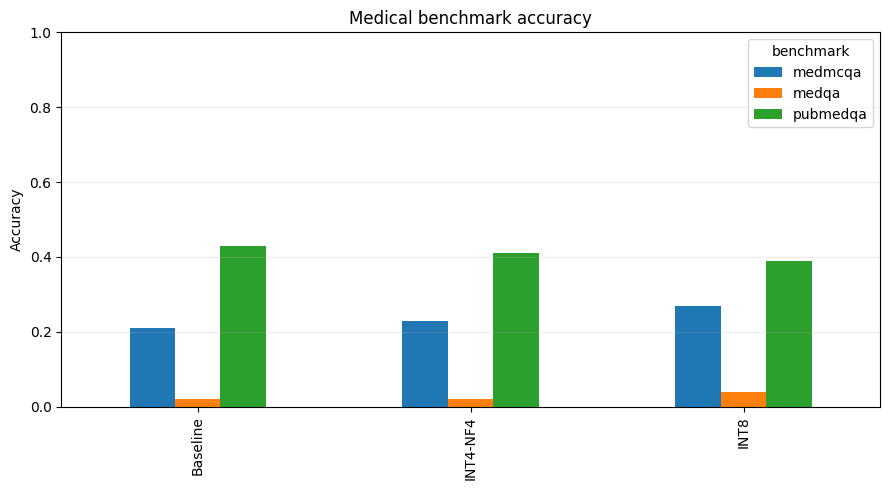

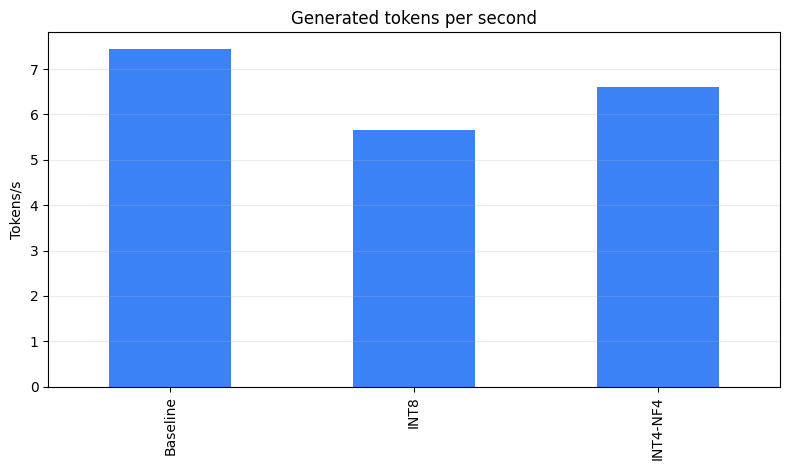

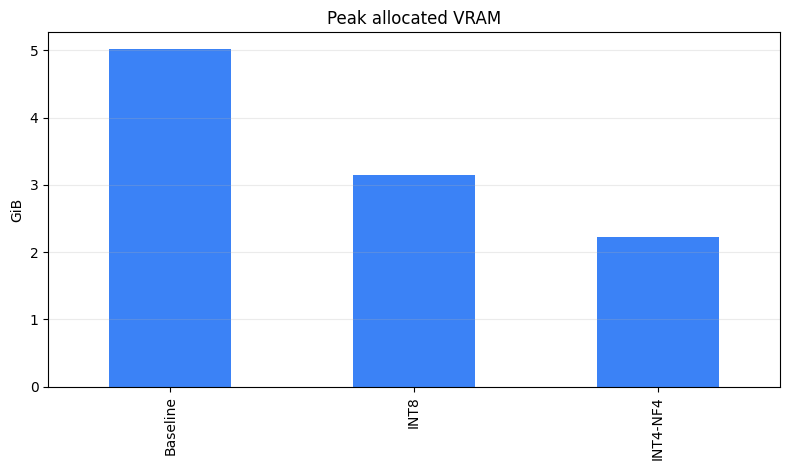

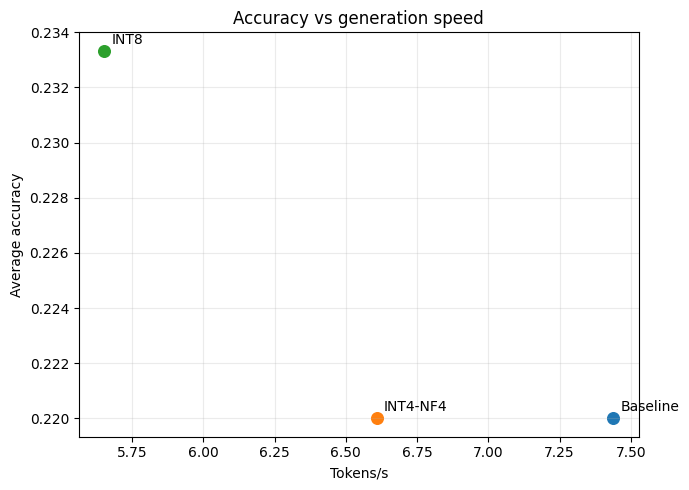

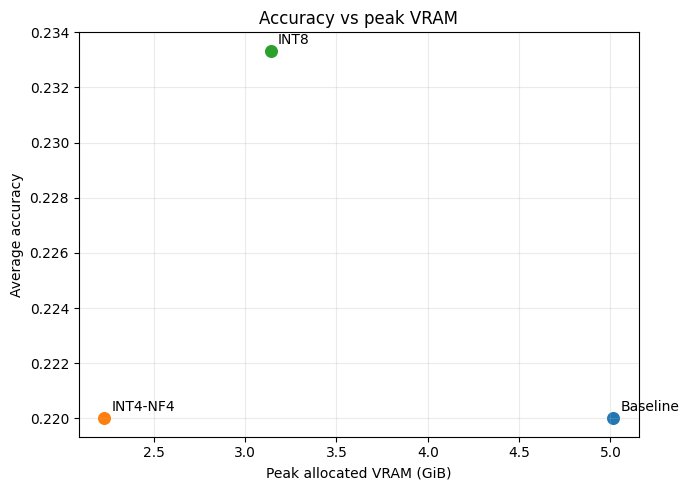

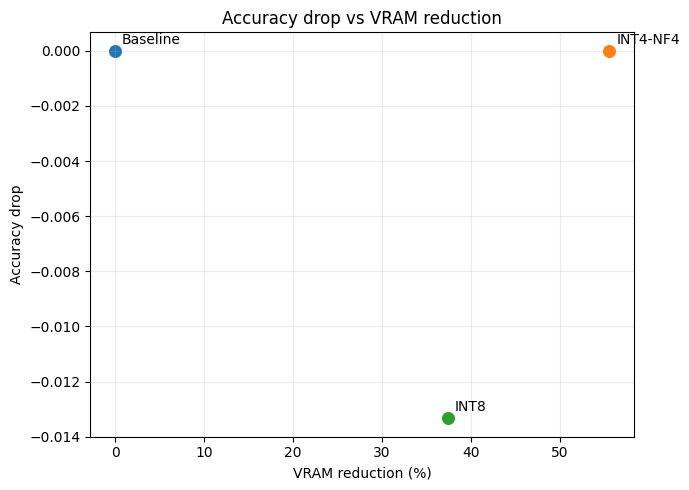

In [20]:
def save_bar(series, title, ylabel, filename):
    fig, ax = plt.subplots(figsize=(8, 4.8))
    series.plot(kind="bar", ax=ax, color="#3b82f6")
    ax.set_title(title); ax.set_ylabel(ylabel); ax.set_xlabel("")
    ax.grid(axis="y", alpha=0.25); fig.tight_layout()
    fig.savefig(Path(OUTPUT_DIR) / filename, dpi=160, bbox_inches="tight")
    plt.show(); plt.close(fig)

def save_scatter(frame, x, y, title, xlabel, ylabel, filename):
    clean = frame.dropna(subset=[x, y])
    fig, ax = plt.subplots(figsize=(7, 5))
    for _, row in clean.iterrows():
        ax.scatter(row[x], row[y], s=70)
        ax.annotate(row["Model Configuration"], (row[x], row[y]), xytext=(5, 5), textcoords="offset points")
    ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); ax.grid(alpha=0.25)
    fig.tight_layout(); fig.savefig(Path(OUTPUT_DIR) / filename, dpi=160, bbox_inches="tight")
    plt.show(); plt.close(fig)

if not benchmark_summary.empty:
    accuracy_plot = benchmark_summary.pivot(index="model_configuration", columns="benchmark", values="accuracy")
    fig, ax = plt.subplots(figsize=(9, 5)); accuracy_plot.plot(kind="bar", ax=ax)
    ax.set_title("Medical benchmark accuracy"); ax.set_ylabel("Accuracy"); ax.set_xlabel("")
    ax.set_ylim(0, 1); ax.grid(axis="y", alpha=0.25); fig.tight_layout()
    fig.savefig(Path(OUTPUT_DIR) / "accuracy_by_configuration.png", dpi=160, bbox_inches="tight")
    plt.show(); plt.close(fig)
if not performance_summary.empty:
    save_bar(performance_summary.set_index("model_configuration")["tokens_per_second"],
             "Generated tokens per second", "Tokens/s", "tokens_per_second.png")
if not memory_summary.empty:
    save_bar(memory_summary.set_index("model_configuration")["peak_allocated_vram_gib"],
             "Peak allocated VRAM", "GiB", "peak_vram.png")

plot_frame = tradeoff_summary.merge(
    performance_summary[["model_configuration", "tokens_per_second"]].rename(columns={"model_configuration": "Model Configuration"}),
    on="Model Configuration", how="left"
) if not tradeoff_summary.empty and not performance_summary.empty else pd.DataFrame()
plot_frame = plot_frame.merge(
    memory_summary[["model_configuration", "peak_allocated_vram_gib"]].rename(columns={"model_configuration": "Model Configuration"}),
    on="Model Configuration", how="left"
) if not plot_frame.empty and not memory_summary.empty else plot_frame
if not plot_frame.empty:
    save_scatter(plot_frame, "tokens_per_second", "Average Accuracy", "Accuracy vs generation speed",
                 "Tokens/s", "Average accuracy", "accuracy_vs_tokens_per_second.png")
    save_scatter(plot_frame, "peak_allocated_vram_gib", "Average Accuracy", "Accuracy vs peak VRAM",
                 "Peak allocated VRAM (GiB)", "Average accuracy", "accuracy_vs_peak_vram.png")
    save_scatter(plot_frame, "VRAM Reduction vs Baseline", "Accuracy Drop vs Baseline",
                 "Accuracy drop vs VRAM reduction", "VRAM reduction (%)", "Accuracy drop",
                 "accuracy_drop_vs_memory_reduction.png")


## 22. Saving results

The cell records environment, checkpoint metadata when accessible, all settings, final tables, and a ZIP archive. The optional Drive cell copies the ZIP only when explicitly run.


In [21]:
def current_environment_info():
    gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else None
    gpu_total = torch.cuda.get_device_properties(0).total_memory/2**30 if torch.cuda.is_available() else None
    try:
        driver = subprocess.check_output(["nvidia-smi", "--query-gpu=driver_version", "--format=csv,noheader"], text=True).strip()
    except Exception:
        driver = None
    return {
        "recorded_at_utc": datetime.now(timezone.utc).isoformat(), "python_version": platform.python_version(),
        "gpu_name": gpu_name, "gpu_total_memory_gib": gpu_total, "cuda_version": torch.version.cuda,
        "driver_version": driver, "pytorch_version": torch.__version__,
        "transformers_version": transformers.__version__, "datasets_version": package_version("datasets"),
        "accelerate_version": package_version("accelerate"), "bitsandbytes_version": package_version("bitsandbytes"),
    }

def resolve_model_commit(model_id):
    try:
        return HfApi().model_info(model_id, revision=MODEL_REVISION).sha
    except Exception as exc:
        return f"Unavailable: {type(exc).__name__}: {exc}"

def resolve_dataset_commits():
    commits = {}
    api = HfApi()
    for benchmark, cfg in DATASET_CONFIGS.items():
        if not cfg.get("path"):
            commits[benchmark] = None
            continue
        try:
            commits[benchmark] = api.dataset_info(cfg["path"], revision=cfg.get("revision")).sha
        except Exception as exc:
            commits[benchmark] = f"Unavailable: {type(exc).__name__}: {exc}"
    return commits

experiment_config = {
    "model_id": MODEL_ID, "requested_model_revision": MODEL_REVISION,
    "resolved_model_commit": resolve_model_commit(MODEL_ID), "run_flags": {
        "baseline": RUN_BASELINE, "int8": RUN_INT8, "int4_nf4": RUN_INT4,
        "awq": RUN_AWQ, "gptq": RUN_GPTQ, "healthbench": RUN_HEALTHBENCH,
    }, "dataset_configs": DATASET_CONFIGS, "resolved_dataset_commits": resolve_dataset_commits(),
    "benchmarks": BENCHMARKS,
    "max_samples_per_dataset": MAX_SAMPLES_PER_DATASET, "batch_size": BATCH_SIZE,
    "random_seed": RANDOM_SEED, "prompt_template": PROMPT_TEMPLATE,
    "generation_parameters": GENERATION_PARAMETERS, "num_warmup_runs": NUM_WARMUP_RUNS,
    "num_timed_runs": NUM_TIMED_RUNS, "sample_counts": {k: len(v) for k, v in normalized_datasets.items()},
    "sample_ids": sample_ids, "same_session_gpu": session_gpu_name,
}
save_json(experiment_config, "experiment_config.json")
save_json(current_environment_info(), "environment_info.json")
print("Final experiment settings:")
print(json.dumps(experiment_config, indent=2, default=str))

# Re-save the required tabular artifacts, including empty files with useful headers where possible.
pd.DataFrame(all_predictions).to_csv(Path(OUTPUT_DIR) / "raw_predictions.csv", index=False)
benchmark_summary.to_csv(Path(OUTPUT_DIR) / "benchmark_summary.csv", index=False)
performance_summary.to_csv(Path(OUTPUT_DIR) / "performance_summary.csv", index=False)
memory_summary.to_csv(Path(OUTPUT_DIR) / "memory_summary.csv", index=False)
tradeoff_summary.to_csv(Path(OUTPUT_DIR) / "tradeoff_summary.csv", index=False)
published_model_comparison.to_csv(Path(OUTPUT_DIR) / "published_model_comparison.csv", index=False)
print("Saved result files:")
for path in sorted(Path(OUTPUT_DIR).glob("*")):
    print(" -", path.name)


Final experiment settings:
{
  "model_id": "google/gemma-2-2b-it",
  "requested_model_revision": null,
  "resolved_model_commit": "299a8560bedf22ed1c72a8a11e7dce4a7f9f51f8",
  "run_flags": {
    "baseline": true,
    "int8": true,
    "int4_nf4": true,
    "awq": true,
    "gptq": true,
    "healthbench": false
  },
  "dataset_configs": {
    "pubmedqa": {
      "path": "qiaojin/PubMedQA",
      "name": "pqa_labeled",
      "split": "train",
      "revision": null
    },
    "medqa": {
      "path": "GBaker/MedQA-USMLE-4-options",
      "name": null,
      "split": "test",
      "revision": null
    },
    "medmcqa": {
      "path": "openlifescienceai/medmcqa",
      "name": null,
      "split": "validation",
      "revision": null
    },
    "healthbench": {
      "path": null,
      "name": null,
      "split": "test",
      "revision": null
    }
  },
  "resolved_dataset_commits": {
    "pubmedqa": "9001f2853fb87cab8d220904e0de81ac6973b318",
    "medqa": "0fb93dd23a7339b6dcd27e241cb

In [23]:
# Optional: copy the results archive to Google Drive after the final-summary cell has created it.
from google.colab import drive
drive.mount('/content/drive')
shutil.copy2(f"{OUTPUT_DIR}.zip", "/content/drive/MyDrive/gemma_medical_benchmark_results.zip")


Mounted at /content/drive


FileNotFoundError: [Errno 2] No such file or directory: '/content/gemma_medical_benchmark_results.zip'

## 23. Experiment summary

Recommendations are generated only from completed configurations. “Limited-memory” favors the lowest measured peak allocated VRAM; “preserve accuracy” favors the highest mean local accuracy. These are experimental summaries, not clinical-safety claims.


In [ ]:
def finite_or_none(value):
    try:
        return float(value) if pd.notna(value) and math.isfinite(float(value)) else None
    except (TypeError, ValueError):
        return None

def make_final_summary():
    summary = {"status": "completed_with_available_results", "failures": experiment_failures}
    if tradeoff_summary.empty:
        summary.update({"status": "no_completed_experiments", "message": "No conclusions were generated."})
        return summary
    valid_acc = tradeoff_summary.dropna(subset=["Average Accuracy"])
    if not valid_acc.empty:
        summary["best_accuracy_configuration"] = valid_acc.loc[valid_acc["Average Accuracy"].idxmax(), "Model Configuration"]
        summary["accuracy_priority_recommendation"] = summary["best_accuracy_configuration"]
    if not performance_summary.empty and performance_summary["tokens_per_second"].notna().any():
        summary["fastest_configuration"] = performance_summary.loc[performance_summary["tokens_per_second"].idxmax(), "model_configuration"]
    if not memory_summary.empty and memory_summary["peak_allocated_vram_gib"].notna().any():
        summary["lowest_memory_configuration"] = memory_summary.loc[memory_summary["peak_allocated_vram_gib"].idxmin(), "model_configuration"]
        summary["limited_colab_memory_recommendation"] = summary["lowest_memory_configuration"]
    indexed = tradeoff_summary.set_index("Model Configuration")
    for label in ("INT8", "INT4-NF4"):
        if label in indexed.index:
            row = indexed.loc[label]
            summary[label] = {
                "accuracy_drop_vs_baseline": finite_or_none(row["Accuracy Drop vs Baseline"]),
                "speedup_vs_baseline": finite_or_none(row["Speedup vs Baseline"]),
                "vram_reduction_percent_vs_baseline": finite_or_none(row["VRAM Reduction vs Baseline"]),
            }
    if "Baseline" not in indexed.index:
        summary["comparison_warning"] = "Baseline did not complete; relative conclusions were not fabricated."
    return summary

final_summary = make_final_summary()
save_json(final_summary, "final_summary.json")
archive_path = shutil.make_archive(OUTPUT_DIR, "zip", root_dir=OUTPUT_DIR)
print(json.dumps(final_summary, indent=2))
print(f"\nDownloadable archive: {archive_path}")


{
  "status": "completed_with_available_results",
  "failures": [
    {
      "model_configuration": "AWQ-INT4",
      "error": "OSError: None is not a local folder and is not a valid model identifier listed on 'https://huggingface.co/models'\nIf this is a private repository, make sure to pass a token having permission to this repo either by logging in with `hf auth login` or by passing `token=<your_token>`",
      "traceback": "Traceback (most recent call last):\n  File \"/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_http.py\", line 795, in hf_raise_for_status\n    response.raise_for_status()\n  File \"/usr/local/lib/python3.12/dist-packages/httpx/_models.py\", line 829, in raise_for_status\n    raise HTTPStatusError(message, request=request, response=self)\nhttpx.HTTPStatusError: Client error '404 Not Found' for url 'https://huggingface.co/None/resolve/main/config.json'\nFor more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/404\n\nThe a

## 24. Limitations and reproducibility notes

- Medical multiple-choice accuracy does not establish clinical safety, factual reliability, calibration, or usefulness in patient care.
- A small sampled subset validates plumbing only. Report confidence intervals, run the intended official split, and consider paired significance tests when making research claims.
- Generation-based multiple-choice scoring is sensitive to instruction following and answer extraction. Logits-based option scoring is a valuable separate protocol but must not be mixed silently with these results.
- CUDA allocated, CUDA reserved, `nvidia-smi` device usage, CPU RSS, and model-cache disk size measure different resources.
- The TTFT estimate is a one-token generation call, not a production streaming-server measurement. Kernel compilation, thermal state, and background activity can affect latency.
- CPU offload changes the hardware path and can invalidate speed comparisons. Keep it disabled for fair comparisons unless every configuration uses the same policy.
- AWQ/GPTQ repositories may use different calibration data or even a different base revision; compare them only after verifying exact checkpoint identity.
- Published scores must remain separate unless their split, prompt, few-shot/CoT/MedPrompt/retrieval setup, model version, and scoring script are aligned.
- Colab sessions can be interrupted. Results are checkpointed after every configuration, but copy the ZIP to persistent Drive storage promptly.
- For strict reproduction, pin `MODEL_REVISION` and dataset revisions to commit hashes, keep the same GPU/session, and retain `experiment_config.json`, `environment_info.json`, `sample_ids.json`, and raw predictions.


# Section 2 — MedGemma Quantization Benchmark

This appended pipeline benchmarks **MedGemma independently** while leaving every original Gemma cell unchanged. It reuses the exact normalized dataset samples, prompts, answer extraction, accuracy evaluator, performance profiler, memory monitor, and generation settings already executed above.

The fixed checkpoint is `google/medgemma-1.5-4b-it`. It is a gated 4B multimodal model based on Gemma 3. Accept the Health AI Developer Foundations terms on its Hugging Face page and authenticate before running this section. The medical multiple-choice evaluation below is text-only; no image inputs are used.

Local Gemma and MedGemma results remain experimental and are kept separate from the manually editable published-results worksheet.


## 25. MedGemma experiment configuration

All three MedGemma configurations are enabled by default. They use the same benchmark rows selected earlier, so do not rerun the dataset-sampling cells with different settings between the two families. Baseline dtype selection follows the same BF16-when-supported, otherwise-FP16 policy as the original pipeline.


In [24]:
MEDGEMMA_MODEL_ID = "google/medgemma-1.5-4b-it"
MEDGEMMA_MODEL_REVISION = None  # Pin a commit hash for strict reproducibility.

RUN_MEDGEMMA_BASELINE = True
RUN_MEDGEMMA_INT8 = True
RUN_MEDGEMMA_INT4 = True

MEDGEMMA_CONFIG = {
    "model_id": MEDGEMMA_MODEL_ID,
    "requested_model_revision": MEDGEMMA_MODEL_REVISION,
    "run_baseline": RUN_MEDGEMMA_BASELINE,
    "run_int8": RUN_MEDGEMMA_INT8,
    "run_int4_nf4": RUN_MEDGEMMA_INT4,
    "benchmarks": list(normalized_datasets),
    "sample_ids": sample_ids,
    "prompt_template": PROMPT_TEMPLATE,
    "generation_parameters": GENERATION_PARAMETERS,
    "batch_size": BATCH_SIZE,
    "random_seed": RANDOM_SEED,
}
save_json(MEDGEMMA_CONFIG, "medgemma_experiment_config.json")
print(json.dumps(MEDGEMMA_CONFIG, indent=2, default=str))


{
  "model_id": "google/medgemma-1.5-4b-it",
  "requested_model_revision": null,
  "run_baseline": true,
  "run_int8": true,
  "run_int4_nf4": true,
  "benchmarks": [
    "pubmedqa",
    "medqa",
    "medmcqa"
  ],
  "sample_ids": {
    "pubmedqa": [
      "21726930",
      "25957366",
      "20549895",
      "14518645",
      "10473855",
      "17089900",
      "28056802",
      "18719011",
      "23949294",
      "17610439",
      "25168472",
      "23774337",
      "23794696",
      "23860049",
      "9569972",
      "14697414",
      "15918864",
      "17054994",
      "12040336",
      "25636371",
      "19542542",
      "9140335",
      "22876568",
      "26063028",
      "12121321",
      "16769333",
      "11943048",
      "17462393",
      "7547656",
      "22658587",
      "12163782",
      "19854401",
      "26079501",
      "24630333",
      "25887165",
      "23791827",
      "27581329",
      "17276801",
      "20538207",
      "8921484",
      "25406780",
      "24996865

## 26. MedGemma processor and model loaders

MedGemma 1.5 is multimodal, so it uses `AutoProcessor` and `AutoModelForMultimodalLM`, not the text-only Gemma loader. `TextOnlyProcessorAdapter` presents the tokenizer-like interface expected by the original evaluation utilities and converts chat messages into the content-list format used by multimodal Gemma templates.


In [25]:
from IPython.display import Markdown, display
from transformers import AutoModelForMultimodalLM, AutoProcessor

class TextOnlyProcessorAdapter:
    '''Expose a tokenizer-compatible interface for text-only MedGemma evaluation.'''
    def __init__(self, processor):
        self.processor = processor
        self.tokenizer = getattr(processor, "tokenizer", processor)
        self.chat_template = getattr(processor, "chat_template", None) or getattr(self.tokenizer, "chat_template", None)

    @property
    def pad_token_id(self):
        return self.tokenizer.pad_token_id

    @property
    def eos_token_id(self):
        return self.tokenizer.eos_token_id

    def __call__(self, text, return_tensors="pt", **kwargs):
        return self.processor(text=text, return_tensors=return_tensors, **kwargs)

    def decode(self, token_ids, **kwargs):
        return self.tokenizer.decode(token_ids, **kwargs)

    def apply_chat_template(self, messages, tokenize=False, add_generation_prompt=True, **kwargs):
        multimodal_messages = []
        for message in messages:
            content = message.get("content", "")
            if isinstance(content, str):
                content = [{"type": "text", "text": content}]
            multimodal_messages.append({"role": message["role"], "content": content})
        return self.processor.apply_chat_template(
            multimodal_messages,
            tokenize=tokenize,
            add_generation_prompt=add_generation_prompt,
            **kwargs,
        )

def medgemma_model_kwargs():
    '''Build MedGemma loading arguments without changing the Gemma globals.'''
    kwargs = {
        "pretrained_model_name_or_path": MEDGEMMA_MODEL_ID,
        "revision": MEDGEMMA_MODEL_REVISION,
        "device_map": "auto" if ENABLE_CPU_OFFLOAD_FALLBACK else {"": 0},
        "low_cpu_mem_usage": True,
        "trust_remote_code": TRUST_REMOTE_CODE,
    }
    if ENABLE_CPU_OFFLOAD_FALLBACK:
        Path(CPU_OFFLOAD_FOLDER).mkdir(parents=True, exist_ok=True)
        kwargs.update({"offload_folder": CPU_OFFLOAD_FOLDER, "offload_state_dict": True})
    return kwargs

def load_medgemma_processor():
    processor = AutoProcessor.from_pretrained(
        MEDGEMMA_MODEL_ID,
        revision=MEDGEMMA_MODEL_REVISION,
        trust_remote_code=TRUST_REMOTE_CODE,
    )
    tokenizer = getattr(processor, "tokenizer", None)
    if tokenizer is not None and tokenizer.pad_token_id is None:
        tokenizer.pad_token = tokenizer.eos_token
    if tokenizer is not None:
        tokenizer.padding_side = "left"
    return TextOnlyProcessorAdapter(processor)

def load_medgemma_baseline_model():
    dtype, dtype_name = choose_baseline_dtype()
    kwargs = medgemma_model_kwargs()
    kwargs["dtype"] = dtype
    model = AutoModelForMultimodalLM.from_pretrained(**kwargs)
    return model.eval(), dtype_name, "None"

def load_medgemma_int8_model():
    if not torch.cuda.is_available():
        raise RuntimeError("MedGemma BitsAndBytes INT8 requires a supported CUDA GPU.")
    kwargs = medgemma_model_kwargs()
    kwargs["quantization_config"] = BitsAndBytesConfig(load_in_8bit=True)
    model = AutoModelForMultimodalLM.from_pretrained(**kwargs)
    return model.eval(), "INT8 weights (mixed compute)", "BitsAndBytes"

def load_medgemma_int4_model():
    if not torch.cuda.is_available():
        raise RuntimeError("MedGemma BitsAndBytes INT4 requires a supported CUDA GPU.")
    compute_dtype = torch.bfloat16 if bf16_supported() else torch.float16
    kwargs = medgemma_model_kwargs()
    kwargs["quantization_config"] = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_use_double_quant=True,
        bnb_4bit_compute_dtype=compute_dtype,
    )
    model = AutoModelForMultimodalLM.from_pretrained(**kwargs)
    return model.eval(), f"INT4 NF4 (compute {str(compute_dtype).replace('torch.', '')})", "BitsAndBytes"


## 27. MedGemma BF16/FP16, INT8, and INT4 evaluation

The family runner executes configurations serially, checkpoints results after each experiment, captures failures, and releases GPU memory before the next load. Accuracy and profiling functions are the same functions used by Gemma above.


In [26]:
MEDGEMMA_EXPERIMENTS = []
if RUN_MEDGEMMA_BASELINE:
    MEDGEMMA_EXPERIMENTS.append(("MedGemma Baseline", load_medgemma_baseline_model))
if RUN_MEDGEMMA_INT8:
    MEDGEMMA_EXPERIMENTS.append(("MedGemma INT8", load_medgemma_int8_model))
if RUN_MEDGEMMA_INT4:
    MEDGEMMA_EXPERIMENTS.append(("MedGemma INT4-NF4", load_medgemma_int4_model))

def save_medgemma_running_results(predictions, performance, memory, failures):
    '''Checkpoint MedGemma artifacts without overwriting original Gemma files.'''
    pd.DataFrame(predictions).to_csv(Path(OUTPUT_DIR) / "medgemma_raw_predictions.csv", index=False)
    pd.DataFrame(summarize_predictions(predictions)).to_csv(
        Path(OUTPUT_DIR) / "medgemma_benchmark_summary.csv", index=False
    )
    pd.DataFrame(performance).to_csv(Path(OUTPUT_DIR) / "medgemma_performance_summary.csv", index=False)
    pd.DataFrame(memory).to_csv(Path(OUTPUT_DIR) / "medgemma_memory_summary.csv", index=False)
    save_json(failures, "medgemma_experiment_failures.json")

def run_model_family_experiments(experiments, processor_loader, model_id):
    '''Run a list of loaders through the shared accuracy and profiling utilities.'''
    predictions, performance, memory, failures = [], [], [], []
    for config_name, model_loader in experiments:
        model = tokenizer = None
        unload_model()
        if torch.cuda.is_available():
            torch.cuda.reset_peak_memory_stats()
        before = gpu_memory_snapshot()
        ram_monitor = PeakRSSMonitor().start()
        try:
            print(f"\n=== {config_name} ===")
            tokenizer = processor_loader()
            cuda_sync()
            load_start = time.perf_counter()
            model, actual_dtype, quant_method = model_loader()
            cuda_sync()
            load_time = time.perf_counter() - load_start
            after_load = gpu_memory_snapshot()

            configuration_predictions = evaluate_accuracy(model, tokenizer, config_name)
            profile = profile_performance(model, tokenizer, config_name)
            profile.update({
                "load_time_seconds": load_time,
                "gpu_name": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
                "model_family": "MedGemma",
            })
            predictions.extend(configuration_predictions)
            performance.append(profile)
            peak_ram = ram_monitor.stop()
            memory.append({
                "model_configuration": config_name,
                "model_family": "MedGemma",
                "actual_dtype": actual_dtype,
                "quantization_method": quant_method,
                "gpu_allocated_before_load_gib": before["allocated_gib"],
                "gpu_device_used_before_load_gib": before["device_used_gib"],
                "gpu_allocated_after_load_gib": after_load["allocated_gib"],
                "gpu_device_used_after_load_gib": after_load["device_used_gib"],
                "peak_allocated_vram_gib": torch.cuda.max_memory_allocated()/2**30 if torch.cuda.is_available() else 0,
                "peak_reserved_vram_gib": torch.cuda.max_memory_reserved()/2**30 if torch.cuda.is_available() else 0,
                "peak_cpu_ram_gib": peak_ram,
                "model_cache_size_gib": cached_model_size_gib(model_id),
            })
        except Exception as exc:
            ram_monitor.stop()
            message = friendly_access_error(exc, model_id)
            if isinstance(exc, torch.cuda.OutOfMemoryError) or "out of memory" in str(exc).lower():
                message = (
                    f"CUDA out of memory during {config_name}. Use a larger Colab GPU, reduce prompt/sample "
                    f"size, or explicitly enable the documented CPU-offload fallback. {exc}"
                )
            elif "bitsandbytes" in str(exc).lower():
                message = f"BitsAndBytes incompatibility during {config_name}: {exc}"
            failures.append({
                "model_configuration": config_name,
                "error": message,
                "traceback": traceback.format_exc(),
            })
            print("FAILED:", message)
        finally:
            save_medgemma_running_results(predictions, performance, memory, failures)
            del model
            del tokenizer
            unload_model()
    return predictions, performance, memory, failures

medgemma_predictions, medgemma_performance_rows, medgemma_memory_rows, medgemma_failures = (
    run_model_family_experiments(
        MEDGEMMA_EXPERIMENTS,
        load_medgemma_processor,
        MEDGEMMA_MODEL_ID,
    )
)



=== MedGemma Baseline ===


processor_config.json:   0%|          | 0.00/70.0 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/2.55k [00:00<?, ?B/s]

...

MedGemma INT4-NF4 · pubmedqa:   0%|          | 0/100 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


MedGemma INT4-NF4 · medqa:   0%|          | 0/100 [00:00<?, ?it/s]

MedGemma INT4-NF4 · medmcqa:   0%|          | 0/100 [00:00<?, ?it/s]

Profiling MedGemma INT4-NF4:   0%|          | 0/5 [00:00<?, ?it/s]

## 28. MedGemma accuracy, performance, and memory summaries

Primary accuracy continues to count invalid responses as incorrect. Performance includes generated tokens/s, TTFT estimate, mean/median/P95 latency, throughput, and load time. Memory includes allocated/reserved VRAM, sampled peak CPU RAM, and Hugging Face model-cache disk size when discoverable.


In [27]:
medgemma_benchmark_summary = pd.DataFrame(summarize_predictions(medgemma_predictions))
medgemma_performance_summary = pd.DataFrame(medgemma_performance_rows)
medgemma_memory_summary = pd.DataFrame(medgemma_memory_rows)

medgemma_benchmark_summary.to_csv(Path(OUTPUT_DIR) / "medgemma_benchmark_summary.csv", index=False)
medgemma_performance_summary.to_csv(Path(OUTPUT_DIR) / "medgemma_performance_summary.csv", index=False)
medgemma_memory_summary.to_csv(Path(OUTPUT_DIR) / "medgemma_memory_summary.csv", index=False)

display(
    medgemma_benchmark_summary.round(4) if not medgemma_benchmark_summary.empty else pd.DataFrame({"status": ["No completed MedGemma predictions"]}),
    medgemma_performance_summary.round(4) if not medgemma_performance_summary.empty else pd.DataFrame({"status": ["No completed MedGemma profiles"]}),
    medgemma_memory_summary.round(4) if not medgemma_memory_summary.empty else pd.DataFrame({"status": ["No completed MedGemma memory profiles"]}),
)


,model_configuration,benchmark,total_evaluated,correct,incorrect,invalid,accuracy,valid_response_rate,accuracy_excluding_invalid,accuracy_ci95_low,accuracy_ci95_high
0,MedGemma Baseline,medmcqa,100,16,16,68,0.16,0.32,0.5000,0.1010,0.2442
1,MedGemma Baseline,medqa,100,20,7,73,0.20,0.27,0.7407,0.1334,0.2888
2,MedGemma Baseline,pubmedqa,100,21,10,69,0.21,0.31,0.6774,0.1417,0.2998
3,MedGemma INT4-NF4,medmcqa,100,8,15,77,0.08,0.23,0.3478,0.0411,0.1500
4,MedGemma INT4-NF4,medqa,100,12,5,83,0.12,0.17,0.7059,0.0700,0.1981
5,MedGemma INT4-NF4,pubmedqa,100,1,3,96,0.01,0.04,0.2500,0.0018,0.0545
6,MedGemma INT8,medmcqa,100,15,12,73,0.15,0.27,0.5556,0.0931,0.2328
7,MedGemma INT8,medqa,100,13,8,79,0.13,0.21,0.6190,0.0776,0.2098
8,MedGemma INT8,pubmedqa,100,19,6,75,0.19,0.25,0.7600,0.1251,0.2778


,model_configuration,tokens_per_second,mean_latency_seconds,median_latency_seconds,p95_latency_seconds,mean_time_to_first_token_seconds,overall_samples_per_second,timed_runs,load_time_seconds,gpu_name,model_family
0,MedGemma Baseline,5.1082,2.0359,2.5450,2.6726,1.2961,0.4912,5,168.9930,Tesla T4,MedGemma
1,MedGemma INT8,3.8659,4.1387,4.0048,4.6085,0.4232,0.2416,5,43.3267,Tesla T4,MedGemma
2,MedGemma INT4-NF4,5.0430,3.1727,3.0864,3.6565,1.3607,0.3152,5,34.5844,Tesla T4,MedGemma


,model_configuration,model_family,actual_dtype,quantization_method,gpu_allocated_before_load_gib,gpu_device_used_before_load_gib,gpu_allocated_after_load_gib,gpu_device_used_after_load_gib,peak_allocated_vram_gib,peak_reserved_vram_gib,peak_cpu_ram_gib,model_cache_size_gib
0,MedGemma Baseline,MedGemma,BF16,None,0.0089,0.1562,8.0185,8.1758,8.1774,8.2969,7.4084,8.0419
1,MedGemma INT8,MedGemma,INT8 weights (mixed compute),BitsAndBytes,0.0089,0.1562,4.6730,4.8477,4.8445,4.9844,7.7224,8.0419
2,MedGemma INT4-NF4,MedGemma,INT4 NF4 (compute bfloat16),BitsAndBytes,0.0089,0.1562,3.0179,3.2207,3.2054,3.3535,7.5847,8.0419


## 29. Two-family experimental comparison tables

The following tables use only locally measured experimental results. Table C reports mean accuracy across PubMedQA, MedQA, and MedMCQA. Table D keeps each model/configuration combination as its own row so precision-specific performance is not hidden by averaging.


In [28]:
CORE_MEDICAL_BENCHMARKS = ["pubmedqa", "medqa", "medmcqa"]

def build_family_accuracy_table(summary, configuration_map):
    '''Build an exact three-benchmark table for one model family.'''
    columns = ["Configuration", "PubMedQA", "MedQA", "MedMCQA"]
    if summary.empty:
        return pd.DataFrame(columns=columns)
    filtered = summary[summary["benchmark"].isin(CORE_MEDICAL_BENCHMARKS)].copy()
    pivot = filtered.pivot(index="model_configuration", columns="benchmark", values="accuracy")
    rows = []
    for display_name, stored_name in configuration_map.items():
        rows.append({
            "Configuration": display_name,
            "PubMedQA": pivot.loc[stored_name, "pubmedqa"] if stored_name in pivot.index and "pubmedqa" in pivot.columns else math.nan,
            "MedQA": pivot.loc[stored_name, "medqa"] if stored_name in pivot.index and "medqa" in pivot.columns else math.nan,
            "MedMCQA": pivot.loc[stored_name, "medmcqa"] if stored_name in pivot.index and "medmcqa" in pivot.columns else math.nan,
        })
    return pd.DataFrame(rows, columns=columns)

GEMMA_CONFIGURATION_MAP = {
    "Baseline BF16/FP16": "Baseline",
    "INT8": "INT8",
    "INT4 NF4": "INT4-NF4",
}
MEDGEMMA_CONFIGURATION_MAP = {
    "Baseline BF16/FP16": "MedGemma Baseline",
    "INT8": "MedGemma INT8",
    "INT4 NF4": "MedGemma INT4-NF4",
}

# Table A — original Gemma experimental results.
table_a_gemma = build_family_accuracy_table(benchmark_summary, GEMMA_CONFIGURATION_MAP)

# Table B — MedGemma experimental results.
table_b_medgemma = build_family_accuracy_table(medgemma_benchmark_summary, MEDGEMMA_CONFIGURATION_MAP)

# Table C — family comparison using average accuracy over the same three benchmarks.
def average_accuracy_lookup(summary):
    if summary.empty:
        return {}
    filtered = summary[summary["benchmark"].isin(CORE_MEDICAL_BENCHMARKS)]
    return filtered.groupby("model_configuration")["accuracy"].mean().to_dict()

gemma_average_accuracy = average_accuracy_lookup(benchmark_summary)
medgemma_average_accuracy = average_accuracy_lookup(medgemma_benchmark_summary)
table_c_family_accuracy = pd.DataFrame([
    {
        "Model": "Gemma",
        "Baseline": gemma_average_accuracy.get("Baseline", math.nan),
        "INT8": gemma_average_accuracy.get("INT8", math.nan),
        "INT4": gemma_average_accuracy.get("INT4-NF4", math.nan),
    },
    {
        "Model": "MedGemma",
        "Baseline": medgemma_average_accuracy.get("MedGemma Baseline", math.nan),
        "INT8": medgemma_average_accuracy.get("MedGemma INT8", math.nan),
        "INT4": medgemma_average_accuracy.get("MedGemma INT4-NF4", math.nan),
    },
])

# Table D — all six local configurations; latency is mean end-to-end generation latency.
def build_performance_rows(family, performance, memory):
    if performance.empty:
        return []
    merged = performance.merge(
        memory[["model_configuration", "peak_allocated_vram_gib", "peak_cpu_ram_gib", "model_cache_size_gib"]]
        if not memory.empty else pd.DataFrame(columns=["model_configuration", "peak_allocated_vram_gib", "peak_cpu_ram_gib", "model_cache_size_gib"]),
        on="model_configuration",
        how="left",
    )
    return [{
        "Model": f"{family} · {row['model_configuration'].replace('MedGemma ', '')}",
        "Tokens/sec": row.get("tokens_per_second", math.nan),
        "TTFT": row.get("mean_time_to_first_token_seconds", math.nan),
        "Latency": row.get("mean_latency_seconds", math.nan),
        "Throughput": row.get("overall_samples_per_second", math.nan),
        "Peak VRAM": row.get("peak_allocated_vram_gib", math.nan),
        "Peak CPU RAM": row.get("peak_cpu_ram_gib", math.nan),
        "Model Size": row.get("model_cache_size_gib", math.nan),
    } for _, row in merged.iterrows()]

table_d_performance = pd.DataFrame(
    build_performance_rows("Gemma", performance_summary, memory_summary)
    + build_performance_rows("MedGemma", medgemma_performance_summary, medgemma_memory_summary)
)

table_a_gemma.to_csv(Path(OUTPUT_DIR) / "table_a_gemma_results.csv", index=False)
table_b_medgemma.to_csv(Path(OUTPUT_DIR) / "table_b_medgemma_results.csv", index=False)
table_c_family_accuracy.to_csv(Path(OUTPUT_DIR) / "table_c_gemma_vs_medgemma.csv", index=False)
table_d_performance.to_csv(Path(OUTPUT_DIR) / "table_d_performance_comparison.csv", index=False)

display(Markdown("### Table A — Gemma Results"), table_a_gemma.round(4))
display(Markdown("### Table B — MedGemma Results"), table_b_medgemma.round(4))
display(Markdown("### Table C — Gemma vs MedGemma (mean local accuracy)"), table_c_family_accuracy.round(4))
display(Markdown("### Table D — Performance Comparison"), table_d_performance.round(4))


### Table A — Gemma Results

,Configuration,PubMedQA,MedQA,MedMCQA
0,Baseline BF16/FP16,0.43,0.02,0.21
1,INT8,0.39,0.04,0.27
2,INT4 NF4,0.41,0.02,0.23


### Table B — MedGemma Results

,Configuration,PubMedQA,MedQA,MedMCQA
0,Baseline BF16/FP16,0.21,0.20,0.16
1,INT8,0.19,0.13,0.15
2,INT4 NF4,0.01,0.12,0.08


### Table C — Gemma vs MedGemma (mean local accuracy)

,Model,Baseline,INT8,INT4
0,Gemma,0.22,0.2333,0.22
1,MedGemma,0.19,0.1567,0.07


### Table D — Performance Comparison

,Model,Tokens/sec,TTFT,Latency,Throughput,Peak VRAM,Peak CPU RAM,Model Size
0,Gemma · Baseline,7.4390,0.8182,1.1830,0.8453,5.0163,6.2565,4.8860
1,Gemma · INT8,5.6523,0.2532,1.9815,0.5047,3.1399,7.6985,4.8860
2,Gemma · INT4-NF4,6.6084,0.8529,1.6948,0.5900,2.2282,7.6872,4.8860
3,MedGemma · Baseline,5.1082,1.2961,2.0359,0.4912,8.1774,7.4084,8.0419
4,MedGemma · INT8,3.8659,0.4232,4.1387,0.2416,4.8445,7.7224,8.0419
5,MedGemma · INT4-NF4,5.0430,1.3607,3.1727,0.3152,3.2054,7.5847,8.0419


## 30. Table E — published models (separate from experiments)

Published scores remain manually editable placeholders. Do not copy values into this table without checking a primary paper or official leaderboard and recording the exact split, prompting method, model version, retrieval/tool use, and evaluation script. These rows are never merged into the local experimental calculations.


In [29]:
table_e_published_models = published_model_comparison.copy()
table_e_published_models.to_csv(Path(OUTPUT_DIR) / "table_e_published_models.csv", index=False)
display(table_e_published_models)


,Model,Benchmark,Published Score,Prompting Method,Evaluation Setting,Source
0,GPT-4,,NaN,,Verify before entry,Add primary paper or official leaderboard URL
1,GPT-4 with MedPrompt,,NaN,,Verify before entry,Add primary paper or official leaderboard URL
2,Med-PaLM 2,,NaN,,Verify before entry,Add primary paper or official leaderboard URL
3,Gemini,,NaN,,Verify before entry,Add primary paper or official leaderboard URL
4,Claude,,NaN,,Verify before entry,Add primary paper or official leaderboard URL
5,Llama,,NaN,,Verify before entry,Add primary paper or official leaderboard URL
6,Qwen,,NaN,,Verify before entry,Add primary paper or official leaderboard URL
7,Other medical LLM,,NaN,,Verify before entry,Add primary paper or official leaderboard URL


## 31. Gemma vs MedGemma visualization

The figure compares mean medical accuracy, generated tokens/s, and peak allocated VRAM for every completed local configuration. Missing experiments are omitted rather than imputed.


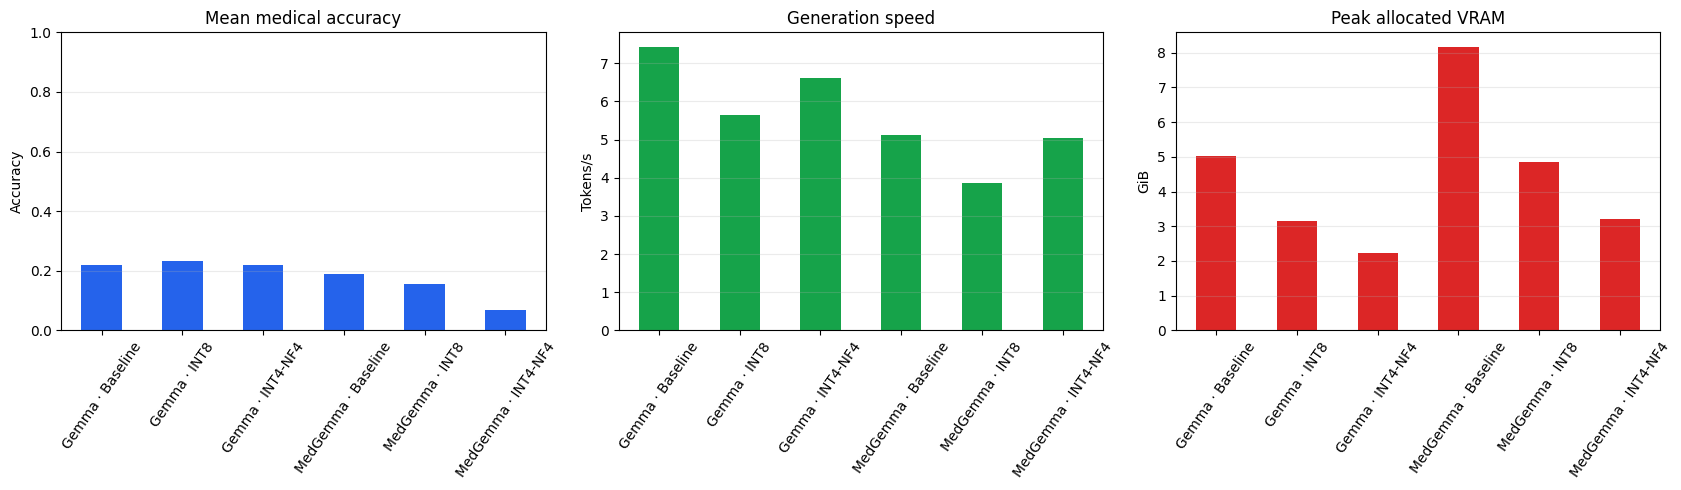

In [30]:
combined_accuracy_lookup = {**gemma_average_accuracy, **medgemma_average_accuracy}
if not table_d_performance.empty:
    configuration_from_label = {
        "Gemma · Baseline": "Baseline",
        "Gemma · INT8": "INT8",
        "Gemma · INT4-NF4": "INT4-NF4",
        "MedGemma · Baseline": "MedGemma Baseline",
        "MedGemma · INT8": "MedGemma INT8",
        "MedGemma · INT4-NF4": "MedGemma INT4-NF4",
    }
    comparison_plot_data = table_d_performance.copy()
    comparison_plot_data["Average Accuracy"] = comparison_plot_data["Model"].map(
        lambda label: combined_accuracy_lookup.get(configuration_from_label.get(label), math.nan)
    )
    comparison_plot_data = comparison_plot_data.dropna(subset=["Average Accuracy", "Tokens/sec", "Peak VRAM"], how="all")
    if not comparison_plot_data.empty:
        fig, axes = plt.subplots(1, 3, figsize=(17, 5))
        comparison_plot_data.set_index("Model")["Average Accuracy"].plot(kind="bar", ax=axes[0], color="#2563eb")
        comparison_plot_data.set_index("Model")["Tokens/sec"].plot(kind="bar", ax=axes[1], color="#16a34a")
        comparison_plot_data.set_index("Model")["Peak VRAM"].plot(kind="bar", ax=axes[2], color="#dc2626")
        axes[0].set_title("Mean medical accuracy"); axes[0].set_ylim(0, 1); axes[0].set_ylabel("Accuracy")
        axes[1].set_title("Generation speed"); axes[1].set_ylabel("Tokens/s")
        axes[2].set_title("Peak allocated VRAM"); axes[2].set_ylabel("GiB")
        for axis in axes:
            axis.set_xlabel(""); axis.grid(axis="y", alpha=0.25); axis.tick_params(axis="x", rotation=55)
        fig.tight_layout()
        fig.savefig(Path(OUTPUT_DIR) / "gemma_vs_medgemma_comparison.png", dpi=160, bbox_inches="tight")
        plt.show(); plt.close(fig)


## 32. Automated two-family analysis

This section discusses only completed experiments. Quantization robustness is defined as the mean absolute accuracy drop from that family’s baseline across completed INT8/INT4 runs. The exploratory trade-off ranking gives equal weight to normalized accuracy, speed, and inverse VRAM; it is transparent but not a clinical decision rule.


In [31]:
def safe_metric(mapping, key):
    value = mapping.get(key, math.nan)
    return float(value) if pd.notna(value) else math.nan

def family_analysis_metrics(family, accuracy_map, performance, memory, names):
    perf = performance.set_index("model_configuration") if not performance.empty else pd.DataFrame()
    mem = memory.set_index("model_configuration") if not memory.empty else pd.DataFrame()
    result = {}
    for short_name, stored_name in names.items():
        result[short_name] = {
            "accuracy": safe_metric(accuracy_map, stored_name),
            "tokens_per_second": float(perf["tokens_per_second"].get(stored_name, math.nan)) if not perf.empty else math.nan,
            "latency_seconds": float(perf["mean_latency_seconds"].get(stored_name, math.nan)) if not perf.empty else math.nan,
            "peak_vram_gib": float(mem["peak_allocated_vram_gib"].get(stored_name, math.nan)) if not mem.empty else math.nan,
        }
    result["family"] = family
    return result

gemma_analysis = family_analysis_metrics(
    "Gemma", gemma_average_accuracy, performance_summary, memory_summary,
    {"Baseline": "Baseline", "INT8": "INT8", "INT4": "INT4-NF4"},
)
medgemma_analysis = family_analysis_metrics(
    "MedGemma", medgemma_average_accuracy, medgemma_performance_summary, medgemma_memory_summary,
    {"Baseline": "MedGemma Baseline", "INT8": "MedGemma INT8", "INT4": "MedGemma INT4-NF4"},
)

def comparison_sentence(metrics, quantized_name):
    baseline, quantized = metrics["Baseline"], metrics[quantized_name]
    if not (pd.notna(baseline["accuracy"]) and pd.notna(quantized["accuracy"])):
        return f"- {metrics['family']} {quantized_name}: unavailable because one or both accuracy runs did not complete."
    accuracy_drop = baseline["accuracy"] - quantized["accuracy"]
    speedup = quantized["tokens_per_second"] / baseline["tokens_per_second"] if baseline["tokens_per_second"] else math.nan
    vram_reduction = (
        (baseline["peak_vram_gib"] - quantized["peak_vram_gib"]) / baseline["peak_vram_gib"] * 100
        if baseline["peak_vram_gib"] else math.nan
    )
    return (
        f"- {metrics['family']} {quantized_name} vs baseline: accuracy drop {accuracy_drop:.4f}; "
        f"speedup {speedup:.2f}×; peak-VRAM reduction {vram_reduction:.1f}%."
    )

analysis_lines = ["## Automated analysis of completed local experiments", ""]
gemma_base = gemma_analysis["Baseline"]["accuracy"]
medgemma_base = medgemma_analysis["Baseline"]["accuracy"]
analysis_lines.append("### 1. Gemma vs MedGemma")
if pd.notna(gemma_base) and pd.notna(medgemma_base):
    winner = "MedGemma" if medgemma_base > gemma_base else "Gemma" if gemma_base > medgemma_base else "Neither (tie)"
    analysis_lines.append(
        f"Baseline mean accuracy: Gemma {gemma_base:.4f}, MedGemma {medgemma_base:.4f}. Higher local baseline: {winner}."
    )
else:
    analysis_lines.append("A baseline-to-baseline conclusion is unavailable because one or both runs did not complete.")

analysis_lines.extend(["", "### 2. BF16/FP16 vs INT8", comparison_sentence(gemma_analysis, "INT8"), comparison_sentence(medgemma_analysis, "INT8")])
analysis_lines.extend(["", "### 3. BF16/FP16 vs INT4 NF4", comparison_sentence(gemma_analysis, "INT4"), comparison_sentence(medgemma_analysis, "INT4")])

analysis_lines.extend(["", "### 4. Quantization robustness"])
robustness = {}
for family_metrics in (gemma_analysis, medgemma_analysis):
    drops = []
    baseline = family_metrics["Baseline"]["accuracy"]
    for quantized_name in ("INT8", "INT4"):
        value = family_metrics[quantized_name]["accuracy"]
        if pd.notna(baseline) and pd.notna(value):
            drops.append(abs(baseline - value))
    if drops:
        robustness[family_metrics["family"]] = statistics.fmean(drops)
if len(robustness) == 2:
    robust_family = min(robustness, key=robustness.get)
    analysis_lines.append(
        f"{robust_family} is more robust under this definition. Mean absolute drops: "
        + ", ".join(f"{name} {drop:.4f}" for name, drop in robustness.items()) + "."
    )
else:
    analysis_lines.append("A two-family robustness conclusion requires completed baselines and quantized runs for both families.")

analysis_lines.extend(["", "### 5. Accuracy–speed–memory trade-off"])
tradeoff_rows = []
for family_metrics in (gemma_analysis, medgemma_analysis):
    for config_name in ("Baseline", "INT8", "INT4"):
        values = family_metrics[config_name]
        if all(pd.notna(values[key]) for key in ("accuracy", "tokens_per_second", "peak_vram_gib")):
            tradeoff_rows.append({"configuration": f"{family_metrics['family']} {config_name}", **values})
tradeoff_frame = pd.DataFrame(tradeoff_rows)
if not tradeoff_frame.empty:
    def minmax(series):
        spread = series.max() - series.min()
        return (series - series.min()) / spread if spread else pd.Series(1.0, index=series.index)
    tradeoff_frame["tradeoff_score"] = (
        minmax(tradeoff_frame["accuracy"])
        + minmax(tradeoff_frame["tokens_per_second"])
        + (1 - minmax(tradeoff_frame["peak_vram_gib"]))
    ) / 3
    best_tradeoff = tradeoff_frame.loc[tradeoff_frame["tradeoff_score"].idxmax()]
    analysis_lines.append(
        f"Equal-weight exploratory ranking selects **{best_tradeoff['configuration']}** "
        f"(accuracy {best_tradeoff['accuracy']:.4f}, {best_tradeoff['tokens_per_second']:.2f} tokens/s, "
        f"{best_tradeoff['peak_vram_gib']:.2f} GiB peak allocated VRAM)."
    )
    analysis_lines.append("Change the weighting before using this ranking for a different deployment priority.")
else:
    analysis_lines.append("No configuration has all three required metrics; no trade-off winner was fabricated.")

two_family_analysis_text = "\n".join(analysis_lines)
display(Markdown(two_family_analysis_text))
(Path(OUTPUT_DIR) / "two_family_analysis.md").write_text(two_family_analysis_text, encoding="utf-8")


## Automated analysis of completed local experiments

### 1. Gemma vs MedGemma
Baseline mean accuracy: Gemma 0.2200, MedGemma 0.1900. Higher local baseline: Gemma.

### 2. BF16/FP16 vs INT8
- Gemma INT8 vs baseline: accuracy drop -0.0133; speedup 0.76×; peak-VRAM reduction 37.4%.
- MedGemma INT8 vs baseline: accuracy drop 0.0333; speedup 0.76×; peak-VRAM reduction 40.8%.

### 3. BF16/FP16 vs INT4 NF4
- Gemma INT4 vs baseline: accuracy drop 0.0000; speedup 0.89×; peak-VRAM reduction 55.6%.
- MedGemma INT4 vs baseline: accuracy drop 0.1200; speedup 0.99×; peak-VRAM reduction 60.8%.

### 4. Quantization robustness
Gemma is more robust under this definition. Mean absolute drops: Gemma 0.0067, MedGemma 0.0767.

### 5. Accuracy–speed–memory trade-off
Equal-weight exploratory ranking selects **Gemma INT4** (accuracy 0.2200, 6.61 tokens/s, 2.23 GiB peak allocated VRAM).
Change the weighting before using this ranking for a different deployment priority.

958

## 33. Save combined results and refreshed archive

This final cell records the resolved MedGemma revision, preserves all original Gemma artifacts, saves combined experimental tables separately from published placeholders, and rebuilds the downloadable ZIP so it includes both model families.


In [32]:
try:
    medgemma_resolved_commit = HfApi().model_info(
        MEDGEMMA_MODEL_ID, revision=MEDGEMMA_MODEL_REVISION
    ).sha
except Exception as exc:
    medgemma_resolved_commit = f"Unavailable: {type(exc).__name__}: {exc}"

MEDGEMMA_CONFIG["resolved_model_commit"] = medgemma_resolved_commit
MEDGEMMA_CONFIG["recorded_at_utc"] = datetime.now(timezone.utc).isoformat()
MEDGEMMA_CONFIG["environment"] = current_environment_info()
MEDGEMMA_CONFIG["failures"] = medgemma_failures
save_json(MEDGEMMA_CONFIG, "medgemma_experiment_config.json")

combined_predictions = pd.concat(
    [pd.DataFrame(all_predictions).assign(model_family="Gemma"),
     pd.DataFrame(medgemma_predictions).assign(model_family="MedGemma")],
    ignore_index=True,
)
combined_benchmark_summary = pd.concat(
    [benchmark_summary.assign(model_family="Gemma"),
     medgemma_benchmark_summary.assign(model_family="MedGemma")],
    ignore_index=True,
)
combined_predictions.to_csv(Path(OUTPUT_DIR) / "two_family_raw_predictions.csv", index=False)
combined_benchmark_summary.to_csv(Path(OUTPUT_DIR) / "two_family_benchmark_summary.csv", index=False)

two_family_final_summary = {
    "gemma_model_id": MODEL_ID,
    "medgemma_model_id": MEDGEMMA_MODEL_ID,
    "same_gpu_session": session_gpu_name,
    "same_sample_ids": sample_ids,
    "gemma_failures": experiment_failures,
    "medgemma_failures": medgemma_failures,
    "table_c_average_accuracy": table_c_family_accuracy.to_dict(orient="records"),
    "analysis_file": "two_family_analysis.md",
    "published_results_are_separate": True,
}
save_json(two_family_final_summary, "two_family_final_summary.json")

archive_path = shutil.make_archive(OUTPUT_DIR, "zip", root_dir=OUTPUT_DIR)
print(f"Updated two-family results archive: {archive_path}")
print("Original Gemma output files were preserved; MedGemma and combined files were added separately.")


Updated two-family results archive: /content/gemma_medical_benchmark_results.zip
Original Gemma output files were preserved; MedGemma and combined files were added separately.


# Section 3 — Publish quantized checkpoints to Hugging Face

BitsAndBytes INT8 and INT4-NF4 weights are serializable under the pinned `transformers==5.14.1`, so each quantized configuration measured above can be pushed once and reloaded directly in every later session. A reloaded repository carries its `quantization_config` inside `config.json`, so `from_pretrained` rebuilds the quantized model without a `BitsAndBytesConfig` argument and without re-quantizing.

This section is **opt-in**. `PUSH_QUANTIZED_TO_HUB` defaults to `False`, so a top-to-bottom Run All prints an upload plan and stops without publishing anything. Repositories are created **private** by default.

Each configuration is re-loaded one at a time because the runners in Sections 1 and 2 deliberately free every model before the next experiment, so no quantized model is still resident by the time execution reaches here.

The upload report records the real on-disk size of each pushed repository. That is the honest answer to the disk-space half of research question 3, which the `Model Size` column of Table D cannot give — BitsAndBytes quantizes in memory and downloads no extra artifact, so that column reports the same source-repository size for every precision.

## 34. Hugging Face publishing configuration

`PUSH_QUANTIZED_TO_HUB` is the master switch; the four per-configuration flags only take effect while it is `True`. Authentication needs a **write**-scoped token — run `notebook_login()` in Section 7 with a write token, or set the `HF_TOKEN` environment variable.

Both source checkpoints are gated releases. Uploading a quantized derivative is permitted, but the redistribution terms travel with it: Gemma derivatives must carry the Gemma Terms of Use and Prohibited Use Policy, and MedGemma derivatives must carry the Health AI Developer Foundations terms. The generated model card includes those notices. Keep the repositories private unless you have read the terms and intend to distribute.

In [34]:
PUSH_QUANTIZED_TO_HUB = True  # Master switch. Nothing is uploaded while this is False.

PUSH_GEMMA_INT8 = True
PUSH_GEMMA_INT4 = True
PUSH_MEDGEMMA_INT8 = True
PUSH_MEDGEMMA_INT4 = True

HUB_NAMESPACE = None  # None resolves the account that owns the authenticated token.
HUB_PRIVATE = True
HUB_COMMIT_MESSAGE = "Add BitsAndBytes quantized checkpoint from the medical benchmark run"

QUANTIZED_REPO_NAMES = {
    "Gemma INT8": "gemma-2-2b-it-bnb-int8",
    "Gemma INT4-NF4": "gemma-2-2b-it-bnb-int4-nf4",
    "MedGemma INT8": "medgemma-1.5-4b-it-bnb-int8",
    "MedGemma INT4-NF4": "medgemma-1.5-4b-it-bnb-int4-nf4",
}

GEMMA_LICENSE = {"license": "gemma", "license_link": "https://ai.google.dev/gemma/terms"}
MEDGEMMA_LICENSE = {
    "license": "other",
    "license_name": "health-ai-developer-foundations",
    "license_link": "https://developers.google.com/health-ai-developer-foundations/terms",
}

GEMMA_LICENSE_NOTICE = (
    "This repository is a quantized derivative of a Gemma model and remains governed by the "
    "Gemma Terms of Use (https://ai.google.dev/gemma/terms) and the Gemma Prohibited Use Policy "
    "(https://ai.google.dev/gemma/prohibited_use_policy). Any further redistribution must carry the "
    "same terms and use restrictions."
)
MEDGEMMA_LICENSE_NOTICE = (
    "This repository is a quantized derivative of MedGemma and remains governed by the Health AI "
    "Developer Foundations Terms of Use "
    "(https://developers.google.com/health-ai-developer-foundations/terms). MedGemma is not a "
    "medical device and its outputs are not clinical advice. Any further redistribution must carry "
    "the same terms and use restrictions."
)

print(f"Publishing enabled: {PUSH_QUANTIZED_TO_HUB}")
print(f"Repositories will be created private: {HUB_PRIVATE}")

Publishing enabled: True
Repositories will be created private: True


## 35. Upload the quantized checkpoints

Validation runs before any model is loaded, so a missing or read-only token fails in seconds rather than after a multi-gigabyte download. Each target then follows the same sequence: create or verify the repository, load the configuration through the **same loader the benchmark used**, push weights and tokenizer/processor, write the model card, measure the published size, and free the GPU before the next target.

`load_medgemma_processor()` returns the `TextOnlyProcessorAdapter` wrapper from Section 26, so the underlying `.processor` is what gets pushed — the adapter is an evaluation-time convenience, not part of the checkpoint.

The card records provenance and quantization settings but deliberately claims **no accuracy numbers**. `extract_answer` in Section 10 mis-parses prose answers, so the measured accuracies are not yet trustworthy enough to publish alongside a model.

In [35]:
QUANTIZED_UPLOAD_TARGETS = [
    {
        "configuration": "Gemma INT8",
        "enabled": PUSH_GEMMA_INT8,
        "repo_name": QUANTIZED_REPO_NAMES["Gemma INT8"],
        "source_model_id": MODEL_ID,
        "source_revision": MODEL_REVISION,
        "model_loader": load_int8_model,
        "companion_loader": lambda: load_tokenizer(MODEL_ID),
        "model_class": AutoModelForCausalLM,
        "companion_class": AutoTokenizer,
        "needs_processor_adapter": False,
        "license_fields": GEMMA_LICENSE,
        "license_notice": GEMMA_LICENSE_NOTICE,
    },
    {
        "configuration": "Gemma INT4-NF4",
        "enabled": PUSH_GEMMA_INT4,
        "repo_name": QUANTIZED_REPO_NAMES["Gemma INT4-NF4"],
        "source_model_id": MODEL_ID,
        "source_revision": MODEL_REVISION,
        "model_loader": load_int4_model,
        "companion_loader": lambda: load_tokenizer(MODEL_ID),
        "model_class": AutoModelForCausalLM,
        "companion_class": AutoTokenizer,
        "needs_processor_adapter": False,
        "license_fields": GEMMA_LICENSE,
        "license_notice": GEMMA_LICENSE_NOTICE,
    },
    {
        "configuration": "MedGemma INT8",
        "enabled": PUSH_MEDGEMMA_INT8,
        "repo_name": QUANTIZED_REPO_NAMES["MedGemma INT8"],
        "source_model_id": MEDGEMMA_MODEL_ID,
        "source_revision": MEDGEMMA_MODEL_REVISION,
        "model_loader": load_medgemma_int8_model,
        "companion_loader": lambda: load_medgemma_processor().processor,
        "model_class": AutoModelForMultimodalLM,
        "companion_class": AutoProcessor,
        "needs_processor_adapter": True,
        "license_fields": MEDGEMMA_LICENSE,
        "license_notice": MEDGEMMA_LICENSE_NOTICE,
    },
    {
        "configuration": "MedGemma INT4-NF4",
        "enabled": PUSH_MEDGEMMA_INT4,
        "repo_name": QUANTIZED_REPO_NAMES["MedGemma INT4-NF4"],
        "source_model_id": MEDGEMMA_MODEL_ID,
        "source_revision": MEDGEMMA_MODEL_REVISION,
        "model_loader": load_medgemma_int4_model,
        "companion_loader": lambda: load_medgemma_processor().processor,
        "model_class": AutoModelForMultimodalLM,
        "companion_class": AutoProcessor,
        "needs_processor_adapter": True,
        "license_fields": MEDGEMMA_LICENSE,
        "license_notice": MEDGEMMA_LICENSE_NOTICE,
    },
]

def resolve_hub_namespace():
    '''Resolve the upload account and confirm write scope before anything expensive runs.'''
    identity = HfApi().whoami()
    namespace = HUB_NAMESPACE or identity.get("name")
    if not namespace:
        raise RuntimeError("Could not resolve a Hugging Face account. Set HUB_NAMESPACE explicitly.")
    role = (identity.get("auth") or {}).get("accessToken", {}).get("role")
    if role is not None and role not in ("write", "admin"):
        raise PermissionError(
            f"The active token has '{role}' scope. Uploading requires a write token; "
            "rerun notebook_login() in Section 7 with one."
        )
    if role is None:
        warnings.warn("Token scope could not be determined; the upload will fail later if it is read-only.")
    return namespace

def build_model_card(target, repo_id, resolved_commit, actual_dtype, quantization_method):
    '''Write a provenance-first card; no accuracy is claimed while extract_answer is unfixed.'''
    frontmatter = {
        "base_model": target["source_model_id"],
        "library_name": "transformers",
        "pipeline_tag": "text-generation",
        "tags": ["bitsandbytes", "quantized", "medical", "gemma"],
        **target["license_fields"],
    }
    yaml_lines = []
    for key, value in frontmatter.items():
        if isinstance(value, list):
            yaml_lines.append(f"{key}:")
            yaml_lines.extend(f"- {item}" for item in value)
        else:
            yaml_lines.append(f"{key}: {value}")
    adapter_note = (
        "\n`AutoProcessor` is used because this is a multimodal checkpoint. The medical "
        "multiple-choice evaluation it was produced for is text-only.\n"
        if target["needs_processor_adapter"] else "\n"
    )
    return f"""---
{chr(10).join(yaml_lines)}
---

# {target['configuration'].replace(' ', ' · ')} (BitsAndBytes)

Quantized derivative of [`{target['source_model_id']}`](https://huggingface.co/{target['source_model_id']}),
produced by the Gemma/MedGemma medical quantization benchmark notebook.

## Provenance

| Field | Value |
|---|---|
| Source model | `{target['source_model_id']}` |
| Source commit | `{resolved_commit}` |
| Quantization | {quantization_method} |
| Stored precision | {actual_dtype} |
| Produced by | `transformers=={transformers.__version__}`, `bitsandbytes=={package_version('bitsandbytes')}` |
| Produced on | {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'} |
| Recorded at | {datetime.now(timezone.utc).isoformat()} |

## Loading

The quantization settings are stored in `config.json`, so no `BitsAndBytesConfig` is needed.
A CUDA GPU and `bitsandbytes` are still required.

```python
from transformers import {target['model_class'].__name__}, {target['companion_class'].__name__}

model = {target['model_class'].__name__}.from_pretrained("{repo_id}", device_map={{"": 0}})
processor = {target['companion_class'].__name__}.from_pretrained("{repo_id}")
```
{adapter_note}
## Evaluation status

No benchmark scores are published here. The notebook that produced this checkpoint has a known
answer-parsing defect, so its accuracy measurements are not yet reliable enough to attach to a
model card. Re-evaluate before making any quality claim.

## License

{target['license_notice']}
"""

def push_quantized_checkpoint(target, namespace, api):
    '''Create the repository, push one quantized configuration, and report its published size.'''
    repo_id = f"{namespace}/{target['repo_name']}"
    print(f"\n=== Publishing {target['configuration']} -> {repo_id} ===")
    api.create_repo(repo_id=repo_id, repo_type="model", private=HUB_PRIVATE, exist_ok=True)
    if HUB_PRIVATE and not api.model_info(repo_id).private:
        raise RuntimeError(
            f"{repo_id} already exists and is public, and create_repo does not change visibility. "
            "Rename the target, or change the repository to private on the Hub, before uploading."
        )

    model = companion = None
    try:
        companion = target["companion_loader"]()
        model, actual_dtype, quantization_method = target["model_loader"]()
        resolved_commit = getattr(model.config, "_commit_hash", None) or target["source_revision"] or "unpinned"

        model.push_to_hub(repo_id, commit_message=HUB_COMMIT_MESSAGE, private=HUB_PRIVATE)
        companion.push_to_hub(repo_id, commit_message=f"{HUB_COMMIT_MESSAGE} (tokenizer/processor)")
        card = build_model_card(target, repo_id, resolved_commit, actual_dtype, quantization_method)
        api.upload_file(
            path_or_fileobj=card.encode("utf-8"),
            path_in_repo="README.md",
            repo_id=repo_id,
            commit_message="Add model card with provenance and license notice",
        )

        info = api.model_info(repo_id, files_metadata=True)
        published_gib = sum(f.size for f in info.siblings if f.size) / 2**30
        print(f"Published {published_gib:.2f} GiB to https://huggingface.co/{repo_id}")
        return {
            "configuration": target["configuration"],
            "repo_id": repo_id,
            "private": HUB_PRIVATE,
            "source_model_id": target["source_model_id"],
            "source_commit": resolved_commit,
            "actual_dtype": actual_dtype,
            "quantization_method": quantization_method,
            "published_size_gib": published_gib,
            "source_cache_size_gib": cached_model_size_gib(target["source_model_id"]),
            "error": None,
        }
    finally:
        del model
        del companion
        unload_model()

hub_upload_records = []
if not PUSH_QUANTIZED_TO_HUB:
    planned = [t["configuration"] for t in QUANTIZED_UPLOAD_TARGETS if t["enabled"]]
    print("PUSH_QUANTIZED_TO_HUB is False; nothing was uploaded.")
    print("Set it to True to publish:", ", ".join(planned) if planned else "(no configuration enabled)")
else:
    hub_namespace = resolve_hub_namespace()  # Fails fast, before any model is loaded.
    hub_api = HfApi()
    print(f"Uploading as: {hub_namespace}")
    for upload_target in QUANTIZED_UPLOAD_TARGETS:
        if not upload_target["enabled"]:
            continue
        try:
            hub_upload_records.append(push_quantized_checkpoint(upload_target, hub_namespace, hub_api))
        except Exception as exc:
            message = friendly_access_error(exc, upload_target["repo_name"])
            hub_upload_records.append({
                "configuration": upload_target["configuration"],
                "repo_id": f"{hub_namespace}/{upload_target['repo_name']}",
                "error": message,
                "traceback": traceback.format_exc(),
            })
            print("FAILED:", message)

    save_json(hub_upload_records, "quantized_hub_uploads.json")
    hub_upload_summary = pd.DataFrame(hub_upload_records)
    display(hub_upload_summary if not hub_upload_summary.empty else pd.DataFrame({"status": ["No uploads attempted"]}))

/tmp/ipykernel_598/398673041.py:73: UserWarning: Token scope could not be determined; the upload will fail later if it is read-only.
  warnings.warn("Token scope could not be determined; the upload will fail later if it is read-only.")


Uploading as: pupupapapa

=== Publishing Gemma INT8 -> pupupapapa/gemma-2-2b-it-bnb-int8 ===


Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

...

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mp6lwfai6z/tokenizer.json:  48%|####7     | 16.0MB / 33.4MB            

Published 3.04 GiB to https://huggingface.co/pupupapapa/medgemma-1.5-4b-it-bnb-int4-nf4


,configuration,repo_id,private,source_model_id,source_commit,actual_dtype,quantization_method,published_size_gib,source_cache_size_gib,error
0,Gemma INT8,pupupapapa/gemma-2-2b-it-bnb-int8,True,google/gemma-2-2b-it,299a8560bedf22ed1c72a8a11e7dce4a7f9f51f8,INT8 weights (mixed compute),BitsAndBytes,3.019042,4.886012,None
1,Gemma INT4-NF4,pupupapapa/gemma-2-2b-it-bnb-int4-nf4,True,google/gemma-2-2b-it,299a8560bedf22ed1c72a8a11e7dce4a7f9f51f8,INT4 NF4 (compute bfloat16),BitsAndBytes,2.103983,4.886012,None
2,MedGemma INT8,pupupapapa/medgemma-1.5-4b-it-bnb-int8,True,google/medgemma-1.5-4b-it,91850547d9f0b2fdd21aa7c5f4f3d1a8a52c243b,INT8 weights (mixed compute),BitsAndBytes,4.674481,8.041890,None
3,MedGemma INT4-NF4,pupupapapa/medgemma-1.5-4b-it-bnb-int4-nf4,True,google/medgemma-1.5-4b-it,91850547d9f0b2fdd21aa7c5f4f3d1a8a52c243b,INT4 NF4 (compute bfloat16),BitsAndBytes,3.038280,8.041890,None


## 36. Verify the round trip

Publishing is only useful if the checkpoint reloads into a working model, so this cell downloads each freshly pushed repository, generates one answer from the first evaluation sample, and reports load time and peak VRAM.

Note what is and is not saved by publishing. Quantization time disappears, and so does the download of the full-precision weights, which is the larger cost. What does **not** disappear is the `bitsandbytes` dependency or the need for a CUDA GPU — a serialized BitsAndBytes checkpoint still dequantizes through the same kernels at load time.

This is opt-in as well, because verification re-downloads everything that was just uploaded.

In [36]:
VERIFY_HUB_ROUNDTRIP = True

def load_published_checkpoint(repo_id, model_class, companion_class, needs_processor_adapter):
    '''Reload a published checkpoint; quantization settings come from the repository config.'''
    companion = companion_class.from_pretrained(repo_id, trust_remote_code=TRUST_REMOTE_CODE)
    tokenizer = getattr(companion, "tokenizer", companion)
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "left"
    model = model_class.from_pretrained(
        repo_id,
        device_map="auto" if ENABLE_CPU_OFFLOAD_FALLBACK else {"": 0},
        trust_remote_code=TRUST_REMOTE_CODE,
    )
    return model.eval(), (TextOnlyProcessorAdapter(companion) if needs_processor_adapter else companion)

roundtrip_rows = []
successful_uploads = [r for r in hub_upload_records if not r.get("error")]
if not VERIFY_HUB_ROUNDTRIP:
    print("VERIFY_HUB_ROUNDTRIP is False; no published checkpoint was reloaded.")
elif not successful_uploads:
    print("No successful upload is available to verify.")
else:
    probe_samples = [item for samples in normalized_datasets.values() for item in samples]
    if not probe_samples:
        raise RuntimeError("No normalized samples are available to probe the reloaded checkpoints.")
    probe_sample = probe_samples[0]
    target_by_configuration = {t["configuration"]: t for t in QUANTIZED_UPLOAD_TARGETS}
    for record in successful_uploads:
        target = target_by_configuration[record["configuration"]]
        model = tokenizer = None
        unload_model()
        if torch.cuda.is_available():
            torch.cuda.reset_peak_memory_stats()
        try:
            print(f"\n=== Reloading {record['repo_id']} ===")
            cuda_sync()
            load_start = time.perf_counter()
            model, tokenizer = load_published_checkpoint(
                record["repo_id"], target["model_class"], target["companion_class"],
                target["needs_processor_adapter"],
            )
            cuda_sync()
            reload_seconds = time.perf_counter() - load_start
            response, _, _ = generate_once(model, tokenizer, format_model_prompt(probe_sample, tokenizer))
            roundtrip_rows.append({
                "configuration": record["configuration"],
                "repo_id": record["repo_id"],
                "reload_seconds": reload_seconds,
                "peak_allocated_vram_gib": torch.cuda.max_memory_allocated()/2**30 if torch.cuda.is_available() else 0,
                "probe_response": response,
                "probe_prediction": extract_answer(response, probe_sample["choices"]),
                "probe_gold_answer": probe_sample["answer"],
                "error": None,
            })
        except Exception as exc:
            roundtrip_rows.append({
                "configuration": record["configuration"],
                "repo_id": record["repo_id"],
                "error": friendly_access_error(exc, record["repo_id"]),
            })
            print("FAILED:", roundtrip_rows[-1]["error"])
        finally:
            del model
            del tokenizer
            unload_model()

    save_json(roundtrip_rows, "quantized_hub_roundtrip.json")
    display(pd.DataFrame(roundtrip_rows))


=== Reloading pupupapapa/gemma-2-2b-it-bnb-int8 ===


config.json:   0%|          | 0.00/2.07k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/518 [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 34.4MB            

tokenizer.json: downloading bytes:           |  0.00B            

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 3.23GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/115 [00:00<?, ?B/s]

,configuration,repo_id,reload_seconds,peak_allocated_vram_gib,probe_response,probe_prediction,probe_gold_answer,error
0,Gemma INT8,pupupapapa/gemma-2-2b-it-bnb-int8,110.339231,3.094456,A,A,A,None
1,Gemma INT4-NF4,pupupapapa/gemma-2-2b-it-bnb-int4-nf4,70.147642,2.193786,A,A,A,None
2,MedGemma INT8,pupupapapa/medgemma-1.5-4b-it-bnb-int8,104.635695,4.772947,The question asks if endometrial polyp formati...,INVALID,A,None
3,MedGemma INT4-NF4,pupupapapa/medgemma-1.5-4b-it-bnb-int4-nf4,105.008910,3.155460,"Based on the provided text, the study found th...",INVALID,A,None


## 37. Reusing the published checkpoints in a later session

Once a configuration is published, a later session skips Sections 11, 13, 14, 26, and 27 entirely and loads the quantized weights directly. The only prerequisites are `transformers`, `bitsandbytes`, a CUDA GPU, and access to the private repository:

```python
from transformers import AutoModelForCausalLM, AutoTokenizer

REPO_ID = "your-account/gemma-2-2b-it-bnb-int4-nf4"

tokenizer = AutoTokenizer.from_pretrained(REPO_ID)
model = AutoModelForCausalLM.from_pretrained(REPO_ID, device_map={"": 0}).eval()
```

For the MedGemma repositories, swap in `AutoModelForMultimodalLM` and `AutoProcessor`, then wrap the processor in `TextOnlyProcessorAdapter` to reuse this notebook's evaluation helpers.

Three caveats worth keeping in view:

1. **A published checkpoint is frozen to the quantization settings it was created with.** Changing `bnb_4bit_use_double_quant` or the compute dtype means re-quantizing from the source model and pushing a new repository — the shipped repository name should change with it.
2. **Reloading is not a substitute for the baseline.** The BF16/FP16 configuration is not published here, because storing it would only duplicate the upstream repository at full size. Comparisons against baseline still need the source model.
3. **These repositories inherit gated-model terms.** Keeping them private is the default for that reason; review the Gemma and Health AI Developer Foundations terms before making any of them public.